# HandsOn 1 — Aplicação do Código de Shor via Simulação Computacional

**Curso:** Pós-Graduação em Computação Quântica — SENAI/CIMATEC    
**Disciplina:** Correção e Mitigação de Erros em Computação Quântica    
**Grupo:** *Davidson Clem, Joao Filipe Muchanga, Jose Hidalgo Suarez e Jullyano Lino*  

---

## Sumário

| # | Seção |
|---|-------|
| 1 | Configuração do Ambiente |
| 2 | Fundamentação Teórica — Ruídos e Código de Shor |
| 3 | Implementação do Código de Shor |
| 4 | Simulações e Análise dos Resultados |
| 5 | Modelo de Ruído Probabilístico e Limiar de Erro |
| 6 | Concatenação de Códigos |
| 7 | Conclusões |

> **Referências:** Gaitan (2008); Roffe (2019); Quantum Computing UK (2020); IBM Quantum Platform (2016).

---


In [ ]:
# CÉLULA 2 — Instalação e Verificação das Dependências
import subprocess, sys

def pip_install(*pkgs):
    subprocess.check_call(
        [sys.executable, "-m", "pip", "install", "--quiet",
         "--break-system-packages", *pkgs],
        stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL
    )

pip_install(
    "qiskit>=2.3,<3.0",
    "qiskit-aer>=0.15",
    "matplotlib",
    "numpy",
    "scipy",
    "seaborn",
    "pandas",
    "tabulate",
    "pylatexenc",
)

import qiskit, qiskit_aer, numpy, scipy, matplotlib, seaborn, pandas, tabulate

print("=" * 55)
print("  Verificação de Versões das Bibliotecas")
print("=" * 55)
libs = [
    ("Qiskit",     qiskit),
    ("Qiskit-Aer", qiskit_aer),
    ("NumPy",      numpy),
    ("SciPy",      scipy),
    ("Matplotlib", matplotlib),
    ("Seaborn",    seaborn),
    ("Pandas",     pandas),
]
for name, mod in libs:
    print(f"  {name:<14} {mod.__version__}")
print("=" * 55)
print("  ✓ Ambiente configurado com sucesso!")


  Verificação de Versões das Bibliotecas
  Qiskit         2.4.1
  Qiskit-Aer     0.17.2
  NumPy          2.0.2
  SciPy          1.16.3
  Matplotlib     3.10.0
  Seaborn        0.13.2
  Pandas         2.2.2
  ✓ Ambiente configurado com sucesso!


In [ ]:
# CÉLULA 3 — Importações Globais e Constantes
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import pandas as pd
from scipy import stats
from tabulate import tabulate
import warnings
warnings.filterwarnings('ignore')

# ── Qiskit ──────────────────────────────────────────────────
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister, transpile
from qiskit.quantum_info import (
    Statevector, DensityMatrix, state_fidelity, partial_trace
)
from qiskit.visualization import plot_histogram

# ── Qiskit-Aer ──────────────────────────────────────────────
from qiskit_aer import AerSimulator
from qiskit_aer.noise import NoiseModel, pauli_error, depolarizing_error

# ── Visualização ─────────────────────────────────────────────
plt.rcParams.update({
    "figure.figsize": (12, 5),
    "font.size": 11,
    "axes.titlesize": 12,
    "axes.labelsize": 11,
    "figure.dpi": 100,
    "savefig.dpi": 150,
    "axes.grid": True,
    "grid.alpha": 0.3,
})
sns.set_theme(style="whitegrid", palette="deep")
PALETTE = {"X": "#e63946", "Y": "#f4a261", "Z": "#2a9d8f",
           "com": "#457b9d", "sem": "#e63946"}

# ── Constantes Globais ─────────────────────────────────────────
SEED        = 42
SHOTS       = 4096
INPUT_ANGLE = np.pi / 3   # Ry(π/3)|0⟩  — estado não trivial

np.random.seed(SEED)

alpha = np.cos(INPUT_ANGLE / 2)   # ≈ 0.866
beta  = np.sin(INPUT_ANGLE / 2)   # ≈ 0.500

F_X_FAIL = (2 * alpha * beta) ** 2          # sin²(π/3) ≈ 0.75
F_Z_FAIL = (alpha**2 - beta**2) ** 2        # cos²(π/3) = 0.25
F_Y_FAIL = 0.0                              # estado ortogonal

print(f"Estado de entrada : Ry(π/3)|0⟩ = cos(π/6)|0⟩ + sin(π/6)|1⟩")
print(f"  α = {alpha:.6f}  |  β = {beta:.6f}")
print(f"  P(|0⟩) = α² = {alpha**2:.4f}  |  P(|1⟩) = β² = {beta**2:.4f}")
print()
print("Fidelidade esperada após erro (SEM correção):")
print(f"  Erro X (bit-flip)      : F_X = {F_X_FAIL:.4f}")
print(f"  Erro Z (phase-flip)    : F_Z = {F_Z_FAIL:.4f}")
print(f"  Erro Y (bit+phase-flip): F_Y = {F_Y_FAIL:.4f}")
print(f"\nShots por simulação estatística: {SHOTS:,}")


Estado de entrada : Ry(π/3)|0⟩ = cos(π/6)|0⟩ + sin(π/6)|1⟩
  α = 0.866025  |  β = 0.500000
  P(|0⟩) = α² = 0.7500  |  P(|1⟩) = β² = 0.2500

Fidelidade esperada após erro (SEM correção):
  Erro X (bit-flip)      : F_X = 0.7500
  Erro Z (phase-flip)    : F_Z = 0.2500
  Erro Y (bit+phase-flip): F_Y = 0.0000

Shots por simulação estatística: 4,096


---
## 2 — Fundamentação Teórica

### 2.1 Ruído em Computação Quântica

Um *qubit* ideal mantém sua coerência indefinidamente. Na prática, as interações com o ambiente (**decoerência**) corrompem o estado quântico. O canal de ruído mais geral é descrito por operadores de Kraus $\{E_k\}$ satisfazendo $\sum_k E_k^\dagger E_k = I$. Para *qubits* únicos, as perturbações elementares são os **erros de Pauli**:

---

#### 2.1.1 Bit-Flip — Canal X

$$\mathcal{E}_X(\rho)=(1-p)\,\rho + p\,X\rho X, \qquad X=\begin{pmatrix}0&1\\1&0\end{pmatrix}$$

- $X|0\rangle=|1\rangle$, $X|1\rangle=|0\rangle$ — inverte as amplitudes.
- **Geometria de Bloch:** rotação de $\pi$ em torno do eixo $X$.
- **Origens físicas:** pulsos de micro-ondas descalibrados; radiação cósmica; interações com fônons em supercondutores.
- **Impacto:** troca binária — o qubit "perde" qual estado estava codificado.

---

#### 2.1.2 Phase-Flip — Canal Z (Dephasing)

$$\mathcal{E}_Z(\rho)=(1-p)\,\rho + p\,Z\rho Z, \qquad Z=\begin{pmatrix}1&0\\0&-1\end{pmatrix}$$

- $Z|0\rangle=|0\rangle$, $Z|1\rangle=-|1\rangle$ — inverte o sinal da amplitude de $|1\rangle$.
- **Geometria de Bloch:** rotação de $\pi$ em torno do eixo $Z$.
- **Origens físicas:** *charge noise*, *flux noise*; $T_2$ limitado; acoplamento TLS.
- **Impacto:** não altera probabilidades de medição em $Z$, mas destrói as interferências quânticas.

---

#### 2.1.3 Bit-Phase-Flip — Canal Y

$$\mathcal{E}_Y(\rho)=(1-p)\,\rho + p\,Y\rho Y, \qquad Y=\begin{pmatrix}0&-i\\i&0\end{pmatrix}=iXZ$$

- $Y|0\rangle=i|1\rangle$, $Y|1\rangle=-i|0\rangle$ — inverte *e* muda a fase.
- **Geometria de Bloch:** rotação de $\pi$ em torno do eixo $Y$.
- **Origens físicas:** canal de amplitude + desfasagem simultâneos; circuitos profundos.
- **Nota:** para $\text{Ry}(\pi/3)|0\rangle$, o erro Y produz um estado ortogonal — fidelidade zero sem correção.

---

### 2.2 O Código de Shor — $[[9,1,3]]$

O **Código de Shor** (Peter Shor, 1995) foi o primeiro código capaz de corrigir **qualquer erro de qubit único**. Codifica **1 qubit lógico** em **9 qubits físicos** com **distância $d=3$** (corrige até $t=1$ erro arbitrário por concatenação de dois códigos de repetição).

#### 2.2.1 Estrutura de Concatenação em Dois Níveis

| Nível | Código | Qubits | Erro Corrigido |
|-------|--------|--------|----------------|
| Externo (fase) | Repetição de 3 qubits — fase | 3 representantes | Phase-flip (Z) |
| Interno (amplitude) | Repetição de 3 qubits — amplitude | 3 qubits/bloco | Bit-flip (X) |

#### 2.2.2 Estados Lógicos

$$|0\rangle_L = \frac{1}{2\sqrt{2}}\bigl(|000\rangle+|111\rangle\bigr)^{\otimes 3}, \qquad |1\rangle_L = \frac{1}{2\sqrt{2}}\bigl(|000\rangle-|111\rangle\bigr)^{\otimes 3}$$

#### 2.2.3 Geradores do Estabilizador

| Tipo | Estabilizador | Ação |
|------|---------------|------|
| Bit-flip — Grupo A | $g_1=Z_0Z_1$, $g_2=Z_1Z_2$ | Detecta X em q[0–2] |
| Bit-flip — Grupo B | $g_3=Z_3Z_4$, $g_4=Z_4Z_5$ | Detecta X em q[3–5] |
| Bit-flip — Grupo C | $g_5=Z_6Z_7$, $g_6=Z_7Z_8$ | Detecta X em q[6–8] |
| Phase-flip A–B | $g_7=X_0X_1X_2X_3X_4X_5$ | Detecta Z em grupo A ou B |
| Phase-flip B–C | $g_8=X_3X_4X_5X_6X_7X_8$ | Detecta Z em grupo B ou C |

---


Vetores de Bloch (teóricos):
  Estado Original            => [+0.8660, +0.0000, +0.5000]  |v|=1.0000
  Após Erro X                => [+0.8660, +0.0000, -0.5000]  |v|=1.0000
  Após Erro Z                => [-0.8660, +0.0000, +0.5000]  |v|=1.0000
  Após Erro Y                => [-0.8660, +0.0000, -0.5000]  |v|=1.0000


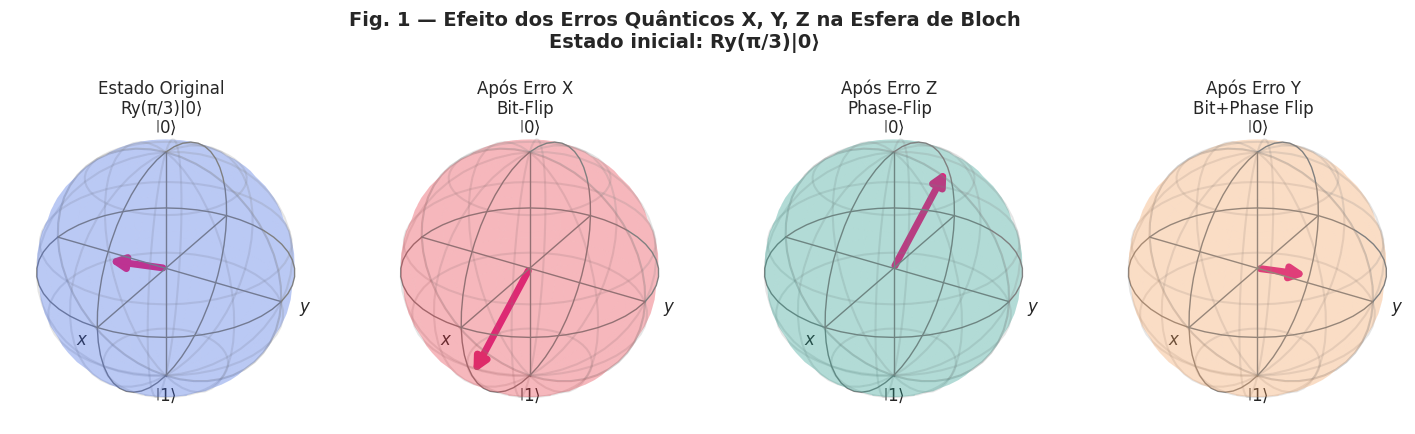


Fig. 1 — Efeito de cada erro Pauli sobre o estado Ry(π/3)|0⟩.
  • Erro X: rotação de π em torno de X (inverte componente Z)
  • Erro Z: rotação de π em torno de Z (inverte componente X)
  • Erro Y: rotação de π em torno de Y (inverte componentes X e Z)


In [ ]:
# CÉLULA 5 — Efeito dos Erros na Esfera de Bloch
import matplotlib.pyplot as plt
from qiskit.visualization import plot_bloch_vector

def bloch_vector(qc_or_sv):
    # Retorna vetor de Bloch [x, y, z] para 1 qubit
    if isinstance(qc_or_sv, QuantumCircuit):
        sv = Statevector(qc_or_sv)
    else:
        sv = qc_or_sv
    rho = DensityMatrix(sv).data
    sx = np.array([[0,1],[1,0]], complex)
    sy = np.array([[0,-1j],[1j,0]], complex)
    sz = np.array([[1,0],[0,-1]], complex)
    return [np.trace(rho@sx).real, np.trace(rho@sy).real, np.trace(rho@sz).real]

def draw_bloch_sphere(ax, bv, title, color='royalblue', marker_size=80):
    # Renderiza esfera de Bloch com o vetor de estado
    u = np.linspace(0, 2*np.pi, 60)
    v = np.linspace(0, np.pi, 30)
    xs = np.outer(np.cos(u), np.sin(v))
    ys = np.outer(np.sin(u), np.sin(v))
    zs = np.outer(np.ones_like(u), np.cos(v))
    ax.plot_surface(xs, ys, zs, alpha=0.06, color='lightsteelblue', zorder=0)
    ax.plot_wireframe(xs, ys, zs, rstride=6, cstride=6,
                      alpha=0.18, linewidth=0.4, color='steelblue')
    for axis, lbl in [([1,0,0],'X'), ([0,1,0],'Y'), ([0,0,1],'Z')]:
        ax.quiver(0,0,0,*axis, length=1.28, arrow_length_ratio=0.12,
                  linewidth=1.2, color='#555', alpha=0.7)
        ax.text(axis[0]*1.45, axis[1]*1.45, axis[2]*1.45, lbl,
                fontsize=9, ha='center', color='#333')
    ax.text(0, 0,  1.55, '|0⟩', fontsize=9, ha='center', color='black', fontweight='bold')
    ax.text(0, 0, -1.60, '|1⟩', fontsize=9, ha='center', color='black', fontweight='bold')
    bx, by, bz = bv
    norm = np.linalg.norm(bv)
    ax.quiver(0,0,0, bx, by, bz, length=1.0, arrow_length_ratio=0.18,
              linewidth=3.0, color=color, zorder=10)
    ax.scatter([bx],[by],[bz], s=marker_size, color=color, zorder=11, edgecolors='white')
    ax.set_xlim([-1.3,1.3]); ax.set_ylim([-1.3,1.3]); ax.set_zlim([-1.3,1.3])
    ax.set_title(f"{title}\n|v|={norm:.3f}", fontsize=10, pad=4)
    ax.set_axis_off()

# Construir os 4 estados
configs = []
for label, gate_fn, color in [
    ("Estado Original\nRy(π/3)|0⟩",  None,               "royalblue"),
    ("Após Erro X\nBit-Flip",         lambda q: q.x(0),   "#e63946"),
    ("Após Erro Z\nPhase-Flip",       lambda q: q.z(0),   "#2a9d8f"),
    ("Após Erro Y\nBit+Phase Flip",   lambda q: q.y(0),   "#f4a261"),
]:
    qc = QuantumCircuit(1)
    qc.ry(INPUT_ANGLE, 0)
    if gate_fn: gate_fn(qc)
    bv = bloch_vector(qc)
    configs.append((label, bv, color))

print("Vetores de Bloch (teóricos):")
for lbl, bv, _ in configs:
    name = lbl.split('\n')[0]
    print(f"  {name:<26} => [{bv[0]:+.4f}, {bv[1]:+.4f}, {bv[2]:+.4f}]  |v|={np.linalg.norm(bv):.4f}")


fig = plt.figure(figsize=(18, 5))

for i, (label, bv, color) in enumerate(configs):
    ax = fig.add_subplot(1, 4, i+1, projection='3d')

    # plot_bloch_vector aceita o parâmetro `ax`
    plot_bloch_vector(bv, title=label, ax=ax, figsize=None)

    # Personalizar cor da seta (funciona na maioria das versões recentes)
    for collection in ax.collections:
        if len(collection.get_facecolors()) > 0:
            collection.set_facecolor(color)
            collection.set_edgecolor('white')

plt.suptitle("Fig. 1 — Efeito dos Erros Quânticos X, Y, Z na Esfera de Bloch\n"
             f"Estado inicial: Ry(π/3)|0⟩",
             fontsize=14, fontweight='bold', y=1.02)

# Removed plt.tight_layout() as it conflicts with 3D plots in this context.
plt.savefig("fig1_bloch_erros.png", dpi=200, bbox_inches='tight')
plt.show()

print("\nFig. 1 — Efeito de cada erro Pauli sobre o estado Ry(π/3)|0⟩.")
print("  • Erro X: rotação de π em torno de X (inverte componente Z)")
print("  • Erro Z: rotação de π em torno de Z (inverte componente X)")
print("  • Erro Y: rotação de π em torno de Y (inverte componentes X e Z)")


---
## 3 — Implementação do Código de Shor

### 3.1 Estrutura dos Registradores

| Grupo | Qubits Físicos | Representante | Papel |
|-------|---------------|--------------|-------|
| A | q[0], q[1], q[2] | q[0] | Bloco 1 — código de amplitude |
| B | q[3], q[4], q[5] | q[3] | Bloco 2 — código de amplitude |
| C | q[6], q[7], q[8] | q[6] | Bloco 3 — código de amplitude |

**q[0] = qubit lógico** (entrada e saída da informação lógica).

### 3.2 Protocolo de Codificação

```
Entrada: α|0⟩ + β|1⟩  em q[0], demais = |0⟩

Passo 1 — Código externo (repetição de fase):
  CNOT(q[0]→q[3]),  CNOT(q[0]→q[6])
  → α|000 000 000⟩ + β|100 000 000⟩

Passo 2 — Hadamard nos representantes (superposição de fase):
  H(q[0]), H(q[3]), H(q[6])
  → α|+,0,0, +,0,0, +,0,0⟩ + β|-,0,0, -,0,0, -,0,0⟩

Passo 3 — CNOT internos (código de amplitude GHZ por grupo):
  CNOT(q[0]→q[1]), CNOT(q[0]→q[2])   [Grupo A]
  CNOT(q[3]→q[4]), CNOT(q[3]→q[5])   [Grupo B]
  CNOT(q[6]→q[7]), CNOT(q[6]→q[8])   [Grupo C]

Estado final:
  α · (|000⟩+|111⟩)⊗³ / (2√2)  +  β · (|000⟩−|111⟩)⊗³ / (2√2)
  = α|0⟩_L + β|1⟩_L
```

### 3.3 Protocolo de Correção

| Tipo de Erro | Síndrome | Correção |
|---|---|---|
| X em q[i] (grupo G) | Geradores ZZ do grupo G negam | X no qubit errado |
| Z em qualquer q[i] do grupo G | Geradores XX A–B ou B–C negam | Z no representante do grupo G |
| Y em q[i] | Ambas as síndromes | X no qubit + Z no representante |

---


In [ ]:
# CÉLULA 7 — Funções do Circuito Quântico do Código de Shor

def shor_encode(qc, q):
    # Codifica q[0] em 9 qubits fisicos — Codigo de Shor [[9,1,3]]
    # Passo 1: CNOT para os representantes dos grupos B e C
    qc.cx(q[0], q[3])
    qc.cx(q[0], q[6])
    # Passo 2: Hadamard nos representantes (codigo externo de fase)
    qc.h(q[0]); qc.h(q[3]); qc.h(q[6])
    # Passo 3: CNOT internos (codigo interno de amplitude)
    qc.cx(q[0], q[1]); qc.cx(q[0], q[2])   # Grupo A
    qc.cx(q[3], q[4]); qc.cx(q[3], q[5])   # Grupo B
    qc.cx(q[6], q[7]); qc.cx(q[6], q[8])   # Grupo C

def shor_decode(qc, q):
    # Decodificacao do Codigo de Shor — inverso exato da codificacao
    qc.cx(q[6], q[8]); qc.cx(q[6], q[7])   # Grupo C inverso
    qc.cx(q[3], q[5]); qc.cx(q[3], q[4])   # Grupo B inverso
    qc.cx(q[0], q[2]); qc.cx(q[0], q[1])   # Grupo A inverso
    qc.h(q[6]); qc.h(q[3]); qc.h(q[0])     # Hadamard inverso
    qc.cx(q[0], q[6])
    qc.cx(q[0], q[3])

def apply_error(qc, q, error_type, qubit_idx):
    # Injeta erro de Pauli {X, Y, Z} no qubit q[qubit_idx]
    e = error_type.upper()
    if   e == 'X': qc.x(q[qubit_idx])
    elif e == 'Z': qc.z(q[qubit_idx])
    elif e == 'Y': qc.y(q[qubit_idx])
    else: raise ValueError(f"Erro invalido: '{error_type}'. Use 'X', 'Y' ou 'Z'.")

def apply_correction(qc, q, error_type, qubit_idx):
    # Correcao Shor para um unico erro de Pauli em q[qubit_idx]
    # Z em qualquer qubit de um grupo tem o mesmo efeito no cat-state.
    # Corrigi-lo no representante eh suficiente.
    group_rep = (qubit_idx // 3) * 3   # representante: 0, 3 ou 6
    e = error_type.upper()
    if e in ('X', 'Y'):
        qc.x(q[qubit_idx])    # desfaz bit-flip no qubit errado
    if e in ('Z', 'Y'):
        qc.z(q[group_rep])    # desfaz phase-flip no representante do grupo

def get_logical_fidelity(qc, input_sv):
    # Fidelidade F(|psi_in>, rho_q0) apos decodificacao
    # 1. Statevector completo de 9 qubits (512 amplitudes)
    # 2. DensityMatrix 512x512
    # 3. Partial trace -> rho_q0 (DensityMatrix 2x2 do qubit logico q[0])
    # 4. F = <psi_in|rho_q0|psi_in>
    sv  = Statevector(qc)
    dm  = DensityMatrix(sv)
    dm0 = partial_trace(dm, list(range(1, 9)))
    return float(state_fidelity(input_sv, dm0))

def build_full_circuit(input_angle=None, error_type=None, qubit_idx=None,
                       apply_corr=True, add_measure=False):
    # Monta circuito completo:
    # Preparacao -> Codificacao -> [Erro] -> [Correcao] -> Decodificacao -> [Medicao]
    if input_angle is None:
        input_angle = INPUT_ANGLE
    q  = QuantumRegister(9, 'q')
    qc = QuantumCircuit(q)
    if add_measure:
        c = ClassicalRegister(1, 'c')
        qc.add_register(c)

    qc.ry(input_angle, q[0])
    qc.barrier(label='Codif.')
    shor_encode(qc, q)

    if error_type is not None and qubit_idx is not None:
        qc.barrier(label=f'{error_type} q[{qubit_idx}]')
        apply_error(qc, q, error_type, qubit_idx)

    if apply_corr and error_type is not None and qubit_idx is not None:
        qc.barrier(label='Corr.')
        apply_correction(qc, q, error_type, qubit_idx)

    qc.barrier(label='Decod.')
    shor_decode(qc, q)

    if add_measure:
        qc.measure(q[0], c[0])

    return qc

def multi_error_circuit(input_angle, error_type, errored_qubits, use_correction):
    # Circuito Shor com multiplos erros (modelo de ruido independente)
    q  = QuantumRegister(9, 'q')
    qc = QuantumCircuit(q)
    qc.ry(input_angle, q[0])
    shor_encode(qc, q)

    for qi in sorted(errored_qubits):
        apply_error(qc, q, error_type, qi)

    if use_correction and len(errored_qubits) > 0:
        groups     = [list(range(0,3)), list(range(3,6)), list(range(6,9))]
        group_reps = [0, 3, 6]
        if error_type.upper() in ('X', 'Y'):
            for group, rep in zip(groups, group_reps):
                x_in_g = [qi for qi in errored_qubits if qi in group]
                if len(x_in_g) == 1:
                    qc.x(q[x_in_g[0]])
        if error_type.upper() in ('Z', 'Y'):
            for group, rep in zip(groups, group_reps):
                z_in_g = sum(1 for qi in errored_qubits if qi in group)
                if z_in_g % 2 == 1:
                    qc.z(q[rep])

    shor_decode(qc, q)
    return qc

# ── Verificacao de sanidade ─────────────────────────────────
_qc_ref = QuantumCircuit(1)
_qc_ref.ry(INPUT_ANGLE, 0)
input_sv = Statevector(_qc_ref)

qc_base  = build_full_circuit(INPUT_ANGLE, None, None, True)
f_base   = get_logical_fidelity(qc_base, input_sv)
assert abs(f_base - 1.0) < 1e-9, f"ERRO: fidelidade base = {f_base:.8f} != 1.0"

print("✓ Funções do Código de Shor definidas e verificadas.")
print(f"  Fidelidade de baseline (sem erro): {f_base:.10f}")
print()
print("  Funções disponíveis:")
print("    shor_encode()          — codificação (CNOT + Hadamard)")
print("    shor_decode()          — decodificação (inverso exato)")
print("    apply_error()          — injeção de erro Pauli {X,Y,Z}")
print("    apply_correction()     — correção por síndrome")
print("    get_logical_fidelity() — F(|ψ_in⟩, ρ_decodificado)")
print("    build_full_circuit()   — circuito completo")
print("    multi_error_circuit()  — circuito com múltiplos erros")


✓ Funções do Código de Shor definidas e verificadas.
  Fidelidade de baseline (sem erro): 1.0000000000

  Funções disponíveis:
    shor_encode()          — codificação (CNOT + Hadamard)
    shor_decode()          — decodificação (inverso exato)
    apply_error()          — injeção de erro Pauli {X,Y,Z}
    apply_correction()     — correção por síndrome
    get_logical_fidelity() — F(|ψ_in⟩, ρ_decodificado)
    build_full_circuit()   — circuito completo
    multi_error_circuit()  — circuito com múltiplos erros


In [ ]:
# CÉLULA 8 — Circuito de Codificação (Fig. 2)

q_enc  = QuantumRegister(9, 'q')
qc_enc = QuantumCircuit(q_enc)
qc_enc.name = "Codificacao Shor [[9,1,3]]"
qc_enc.ry(INPUT_ANGLE, q_enc[0])
qc_enc.barrier(label='Entrada')
shor_encode(qc_enc, q_enc)

print("=" * 65)
print("  Fig. 2 — Circuito de Codificação — Código de Shor [[9,1,3]]")
print("=" * 65)
print(qc_enc.draw('text', fold=90))
print()
ops = qc_enc.count_ops()
print("  Contagem de portas:")
for gate, cnt in sorted(ops.items()):
    print(f"    {gate:<10} {cnt}×")
print(f"  Profundidade (depth): {qc_enc.depth()}")
print(f"  Total qubits:        {qc_enc.num_qubits}")
print(f"  Total operações:     {sum(ops.values())}")

try:
    fig_enc = qc_enc.draw('mpl', filename='fig2_circuito_codificacao.png', fold=90,
                          style='default',scale=0.65, idle_wires=False)
    fig_enc.suptitle("Fig. 2 — Circuito de Codificação — Código de Shor [[9,1,3]]",
                     fontsize=11, y=1.01)
    #plt.savefig("fig2_circuito_codificacao.png", dpi=150, bbox_inches='tight')
    plt.show()
except Exception as e:
    print(f"[Aviso matplotlib]: {e}")


  Fig. 2 — Circuito de Codificação — Código de Shor [[9,1,3]]
     ┌─────────┐ Entrada           ┌───┐          
q_0: ┤ Ry(π/3) ├────░──────■────■──┤ H ├──■────■──
     └─────────┘    ░      │    │  └───┘┌─┴─┐  │  
q_1: ───────────────░──────┼────┼───────┤ X ├──┼──
                    ░      │    │       └───┘┌─┴─┐
q_2: ───────────────░──────┼────┼────────────┤ X ├
                    ░    ┌─┴─┐  │  ┌───┐     └───┘
q_3: ───────────────░────┤ X ├──┼──┤ H ├──■────■──
                    ░    └───┘  │  └───┘┌─┴─┐  │  
q_4: ───────────────░───────────┼───────┤ X ├──┼──
                    ░           │       └───┘┌─┴─┐
q_5: ───────────────░───────────┼────────────┤ X ├
                    ░         ┌─┴─┐┌───┐     └───┘
q_6: ───────────────░─────────┤ X ├┤ H ├──■────■──
                    ░         └───┘└───┘┌─┴─┐  │  
q_7: ───────────────░───────────────────┤ X ├──┼──
                    ░                   └───┘┌─┴─┐
q_8: ───────────────░────────────────────────┤ X ├
                    

In [ ]:
# CÉLULA 9 — Circuitos Completos para X, Y e Z (Fig. 3)

print("=" * 65)
print("  Fig. 3 — Circuitos Completos — Código de Shor [[9,1,3]]")
print("  (erro no qubit q[0], representante do Grupo A)")
print("=" * 65)

error_labels_map = {'X': 'Bit-Flip (X)', 'Y': 'Bit+Phase (Y)', 'Z': 'Phase-Flip (Z)'}
stage_circuits = {}

for err in ['X', 'Y', 'Z']:
    qc_full = build_full_circuit(INPUT_ANGLE, err, 0, apply_corr=True)
    qc_full.name = f"Shor — Erro {err} em q[0]"
    stage_circuits[err] = qc_full
    print(f"\n--- Erro {err} em q[0] (COM correção) ---")
    print(qc_full.draw('text', fold=100))
    ops = qc_full.count_ops()
    print(f"  Depth: {qc_full.depth()} | Ops: {dict(ops)}")

"""
# Figura matplotlib — um subplot por tipo de erro
for err, qc_full in stage_circuits.items():
    try:
        fig_f = qc_full.draw('mpl', filename=f"fig3_circuito_{err}.png", fold=45,
                             scale=0.65, idle_wires=False, style='default')
        fig_f.suptitle(
            f"Fig. 3{err} — Circuito Completo — Erro {err}: {error_labels_map[err]}",
            fontsize=11
        )
        #plt.savefig(f"fig3_circuito_{err}.png", dpi=150, bbox_inches='tight')
        plt.show()
    except Exception as e:
        print(f"[Aviso {err}]: {e}")
"""

for err, qc_full in stage_circuits.items():
    try:
        # Desenha o circuito e pega a figura
        fig_f = qc_full.draw('mpl',
                             filename=None,           # None para não salvar ainda
                             fold=45,
                             scale=0.65,
                             idle_wires=False,
                             style='default')

        # Adiciona o suptitle
        fig_f.suptitle(
            f"Fig. 3{err} — Circuito Completo — Erro {err}: {error_labels_map[err]}",
            fontsize=12,
            fontweight='bold',
            y=0.95                    # importante: controla a posição vertical
        )

        # Dá espaço para o título superior
        fig_f.subplots_adjust(top=0.88)   # ajuste este valor conforme necessário

        # Salva com boa qualidade
        fig_f.savefig(f"fig3_circuito_{err}.png",
                      dpi=180,
                      bbox_inches='tight')

        plt.show()
        plt.close(fig_f)   # evita figuras duplicadas no notebook

    except Exception as e:
        print(f"[Aviso {err}]: {e}")

# Verificação de paridade: fidelidade com correção deve ser 1.0
print("\n" + "=" * 55)
print("  Verificação: Fidelidade COM correção para q[0], q[3], q[6]")
print("=" * 55)
for err in ['X', 'Y', 'Z']:
    for q_idx in [0, 3, 6]:
        qc_ok = build_full_circuit(INPUT_ANGLE, err, q_idx, apply_corr=True)
        f_ok  = get_logical_fidelity(qc_ok, input_sv)
        status = "✓" if abs(f_ok - 1.0) < 1e-6 else "✗"
        print(f"  {status} Erro {err} em q[{q_idx}] | F = {f_ok:.8f}")


  Fig. 3 — Circuitos Completos — Código de Shor [[9,1,3]]
  (erro no qubit q[0], representante do Grupo A)

--- Erro X em q[0] (COM correção) ---
     ┌─────────┐ Codif.           ┌───┐           X q[0] ┌───┐ Corr. ┌───┐ Decod.           ┌───┐»
q_0: ┤ Ry(π/3) ├───░──────■────■──┤ H ├──■────■─────░────┤ X ├───░───┤ X ├───░──────■────■──┤ H ├»
     └─────────┘   ░      │    │  └───┘┌─┴─┐  │     ░    └───┘   ░   └───┘   ░      │  ┌─┴─┐└───┘»
q_1: ──────────────░──────┼────┼───────┤ X ├──┼─────░────────────░───────────░──────┼──┤ X ├─────»
                   ░      │    │       └───┘┌─┴─┐   ░            ░           ░    ┌─┴─┐└───┘     »
q_2: ──────────────░──────┼────┼────────────┤ X ├───░────────────░───────────░────┤ X ├──────────»
                   ░    ┌─┴─┐  │  ┌───┐     └───┘   ░            ░           ░    └───┘     ┌───┐»
q_3: ──────────────░────┤ X ├──┼──┤ H ├──■────■─────░────────────░───────────░──────■────■──┤ H ├»
                   ░    └───┘  │  └───┘┌─┴─┐  │     ░         

---
## 4 — Simulações e Análise dos Resultados

### 4.1 Protocolo

Para cada cenário de erro, o pipeline executado é:

$$\underbrace{R_y(\pi/3)|0\rangle}_{\text{Preparação}} \xrightarrow{\text{Codificação}} \underbrace{|\psi_L\rangle}_{\text{Estado lógico}} \xrightarrow{E_i} \underbrace{E_i|\psi_L\rangle}_{\text{Corrompido}} \xrightarrow{\text{Correção+Decodificação}} \underbrace{\rho_0}_{\text{Qubit lógico}}$$

A **fidelidade lógica** mede a preservação do estado:

$$F = \langle\psi_\text{in}|\rho_0|\psi_\text{in}\rangle \in [0, 1]$$

### 4.2 Cenários Testados

- **3 tipos de erro** × **9 posições** = **27 cenários** (com + sem correção = 54 simulações)
- Simulação exata via **Statevector** (512 amplitudes — espaço de 9 qubits)
- Fidelidade lógica via **Partial Trace** em q[0]

| Cenário | Descrição | Esperado |
|---------|-----------|---------|
| Com correção Shor | Correção antes da decodificação | $F = 1.000$ |
| Sem correção | Decodificação sem correção | $F < 1.0$ |

---


In [ ]:
# CÉLULA 11 — Análise Sistemática de Fidelidade (27 cenários)

GROUP_NAME = ['A','A','A','B','B','B','C','C','C']
records = []

print("Calculando fidelidades para todos os 27 cenários de erro...")
print("-" * 68)

for error_type in ['X', 'Y', 'Z']:
    for q_idx in range(9):
        grp = GROUP_NAME[q_idx]

        qc_c = build_full_circuit(INPUT_ANGLE, error_type, q_idx, apply_corr=True)
        f_c  = get_logical_fidelity(qc_c, input_sv)

        qc_n = build_full_circuit(INPUT_ANGLE, error_type, q_idx, apply_corr=False)
        f_n  = get_logical_fidelity(qc_n, input_sv)

        corr_ok = abs(f_c - 1.0) < 1e-6
        records.append({
            'Erro':       error_type,
            'Qubit':      q_idx,
            'Grupo':      grp,
            'F_com_corr': f_c,
            'F_sem_corr': f_n,
            'Corr_OK':    corr_ok,
            'Ganho_F':    f_c - f_n,
        })
        status = "✓" if corr_ok else "✗"
        print(f"  {status} Erro {error_type} | q[{q_idx}] (Grupo {grp}) | "
              f"F_corr={f_c:.6f} | F_sem={f_n:.6f} | Ganho={f_c-f_n:+.4f}")

df = pd.DataFrame(records)

print()
print("=" * 80)
print("  TABELA COMPLETA DE FIDELIDADE — CÓDIGO DE SHOR [[9,1,3]]")
print("=" * 80)
df_show = df.copy()
df_show.columns = ['Erro','Qubit','Grupo','F (com correção)','F (sem correção)','Correção OK','Ganho ΔF']
print(tabulate(df_show.to_dict('records'), headers='keys',
               tablefmt='rounded_grid', floatfmt='.6f'))

# Resumo estatístico por tipo de erro
print()
print("=" * 65)
print("  RESUMO ESTATÍSTICO POR TIPO DE ERRO")
print("=" * 65)
for err in ['X', 'Y', 'Z']:
    sub = df[df['Erro'] == err]
    print(f"\n  Erro {err}:")
    print(f"    F média (COM correção): {sub['F_com_corr'].mean():.8f}  "
          f"[min: {sub['F_com_corr'].min():.8f}]")
    print(f"    F média (SEM correção): {sub['F_sem_corr'].mean():.6f}  "
          f"[max: {sub['F_sem_corr'].max():.6f}]")
    print(f"    Correções OK: {sub['Corr_OK'].sum()}/9")
    print(f"    Ganho médio ΔF: {sub['Ganho_F'].mean():+.6f}")

print()
print("  Valores teóricos F_sem_corr para Ry(π/3)|0⟩:")
print(f"    Erro X: F_X = sin²(π/3) = {F_X_FAIL:.6f}")
print(f"    Erro Z: F_Z = cos²(π/3) = {F_Z_FAIL:.6f}")
print(f"    Erro Y: F_Y = 0          = {F_Y_FAIL:.6f}")


Calculando fidelidades para todos os 27 cenários de erro...
--------------------------------------------------------------------
  ✓ Erro X | q[0] (Grupo A) | F_corr=1.000000 | F_sem=0.250000 | Ganho=+0.7500
  ✓ Erro X | q[1] (Grupo A) | F_corr=1.000000 | F_sem=1.000000 | Ganho=+0.0000
  ✓ Erro X | q[2] (Grupo A) | F_corr=1.000000 | F_sem=1.000000 | Ganho=+0.0000
  ✓ Erro X | q[3] (Grupo B) | F_corr=1.000000 | F_sem=0.250000 | Ganho=+0.7500
  ✓ Erro X | q[4] (Grupo B) | F_corr=1.000000 | F_sem=1.000000 | Ganho=+0.0000
  ✓ Erro X | q[5] (Grupo B) | F_corr=1.000000 | F_sem=1.000000 | Ganho=+0.0000
  ✓ Erro X | q[6] (Grupo C) | F_corr=1.000000 | F_sem=0.250000 | Ganho=+0.7500
  ✓ Erro X | q[7] (Grupo C) | F_corr=1.000000 | F_sem=1.000000 | Ganho=+0.0000
  ✓ Erro X | q[8] (Grupo C) | F_corr=1.000000 | F_sem=1.000000 | Ganho=+0.0000
  ✓ Erro Y | q[0] (Grupo A) | F_corr=1.000000 | F_sem=-0.000000 | Ganho=+1.0000
  ✓ Erro Y | q[1] (Grupo A) | F_corr=1.000000 | F_sem=0.750000 | Ganho=+0.2500
 

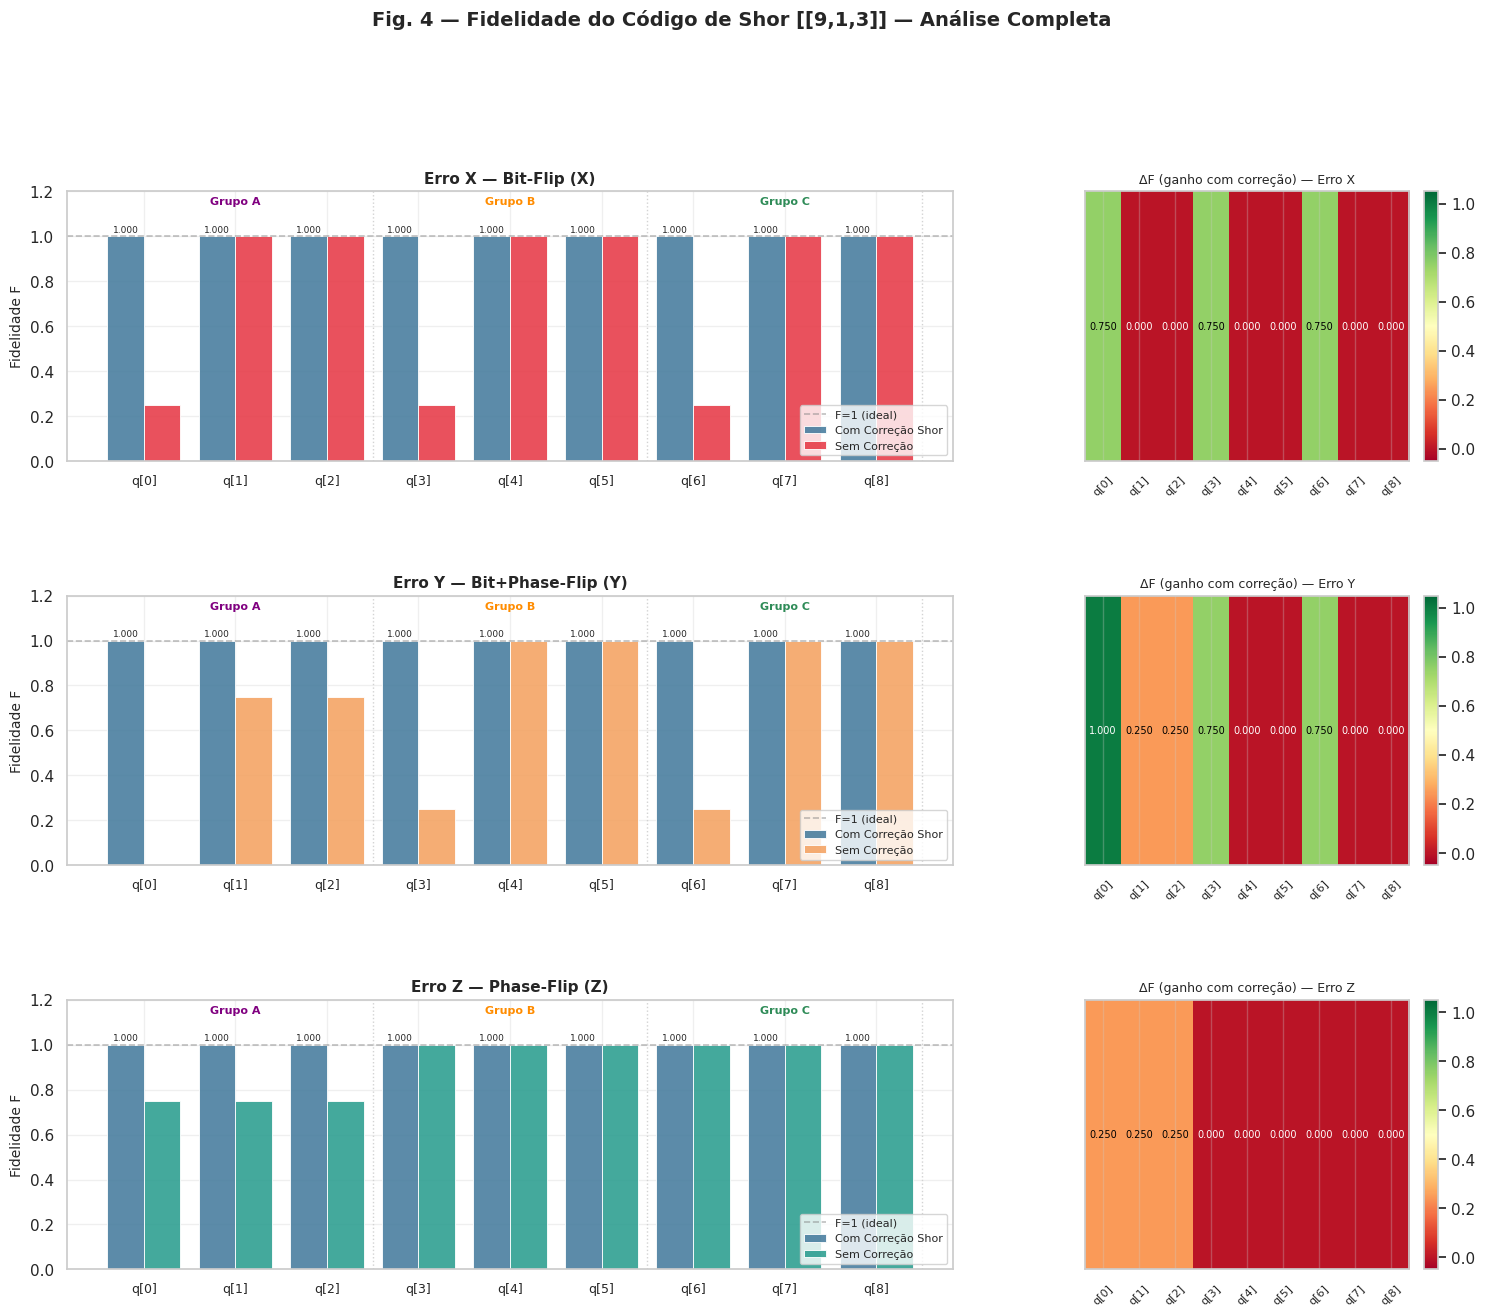

Fig. 4 — Barras azuis: F≈1.0 COM correção Shor (todos os 27 cenários).
         Barras coloridas: F sem correção (X≈0.75, Z≈0.25, Y≈0.00).


In [ ]:
# CÉLULA 12 — Fig. 4 — Fidelidade: barras por cenário + heatmap de ganho

fig = plt.figure(figsize=(18, 14))
gs  = gridspec.GridSpec(3, 3, figure=fig, hspace=0.5, wspace=0.35)

error_meta = {
    'X': ('Bit-Flip (X)',       '#e63946'),
    'Y': ('Bit+Phase-Flip (Y)', '#f4a261'),
    'Z': ('Phase-Flip (Z)',     '#2a9d8f'),
}

fig.suptitle("Fig. 4 — Fidelidade do Código de Shor [[9,1,3]] — Análise Completa",
             fontsize=14, fontweight='bold', y=1.01)

for row, (err, (label, color)) in enumerate(error_meta.items()):
    sub = df[df['Erro'] == err].sort_values('Qubit')
    f_corr   = sub['F_com_corr'].values
    f_nocorr = sub['F_sem_corr'].values
    x = np.arange(9)

    # Gráfico de barras
    ax = fig.add_subplot(gs[row, :2])
    w = 0.4
    ax.bar(x - w/2, f_corr,   w, label='Com Correção Shor', color='#457b9d',
           alpha=0.88, edgecolor='white', linewidth=0.7)
    ax.bar(x + w/2, f_nocorr, w, label='Sem Correção',      color=color,
           alpha=0.88, edgecolor='white', linewidth=0.7)
    ax.axhline(y=1.0, color='gray', ls='--', lw=1.2, alpha=0.5, label='F=1 (ideal)')
    ax.set_xticks(x)
    ax.set_xticklabels([f'q[{i}]' for i in range(9)], fontsize=9)
    ax.set_ylim([0, 1.20])
    ax.set_ylabel('Fidelidade F', fontsize=10)
    ax.set_title(f'Erro {err} — {label}', fontsize=11, fontweight='bold')
    ax.legend(fontsize=8, loc='lower right')
    for gx, gn, gc in [(1,'Grupo A','purple'), (4,'Grupo B','darkorange'), (7,'Grupo C','seagreen')]:
        ax.axvline(x=gx+1.5, color='lightgray', ls=':', lw=1)
        ax.text(gx, 1.14, gn, ha='center', fontsize=8, color=gc, fontweight='bold')
    for xi, fc in zip(x, f_corr):
        ax.text(xi - w/2, fc + 0.01, f'{fc:.3f}', ha='center', va='bottom', fontsize=6.5)

    # Heatmap de ganho ΔF
    ax2 = fig.add_subplot(gs[row, 2])
    gains = sub['Ganho_F'].values.reshape(1, 9)
    im = ax2.imshow(gains, aspect='auto', cmap='RdYlGn', vmin=-0.05, vmax=1.05)
    ax2.set_xticks(range(9))
    ax2.set_xticklabels([f'q[{i}]' for i in range(9)], fontsize=8, rotation=45)
    ax2.set_yticks([])
    ax2.set_title(f'ΔF (ganho com correção) — Erro {err}', fontsize=9)
    for j, g in enumerate(gains[0]):
        ax2.text(j, 0, f'{g:.3f}', ha='center', va='center', fontsize=7,
                 color='black' if 0.2 < g < 0.8 else 'white')
    plt.colorbar(im, ax=ax2, fraction=0.1, pad=0.04)

plt.savefig("fig4_fidelidade_analise.png", dpi=150, bbox_inches='tight')
plt.show()
print("Fig. 4 — Barras azuis: F≈1.0 COM correção Shor (todos os 27 cenários).")
print("         Barras coloridas: F sem correção (X≈0.75, Z≈0.25, Y≈0.00).")


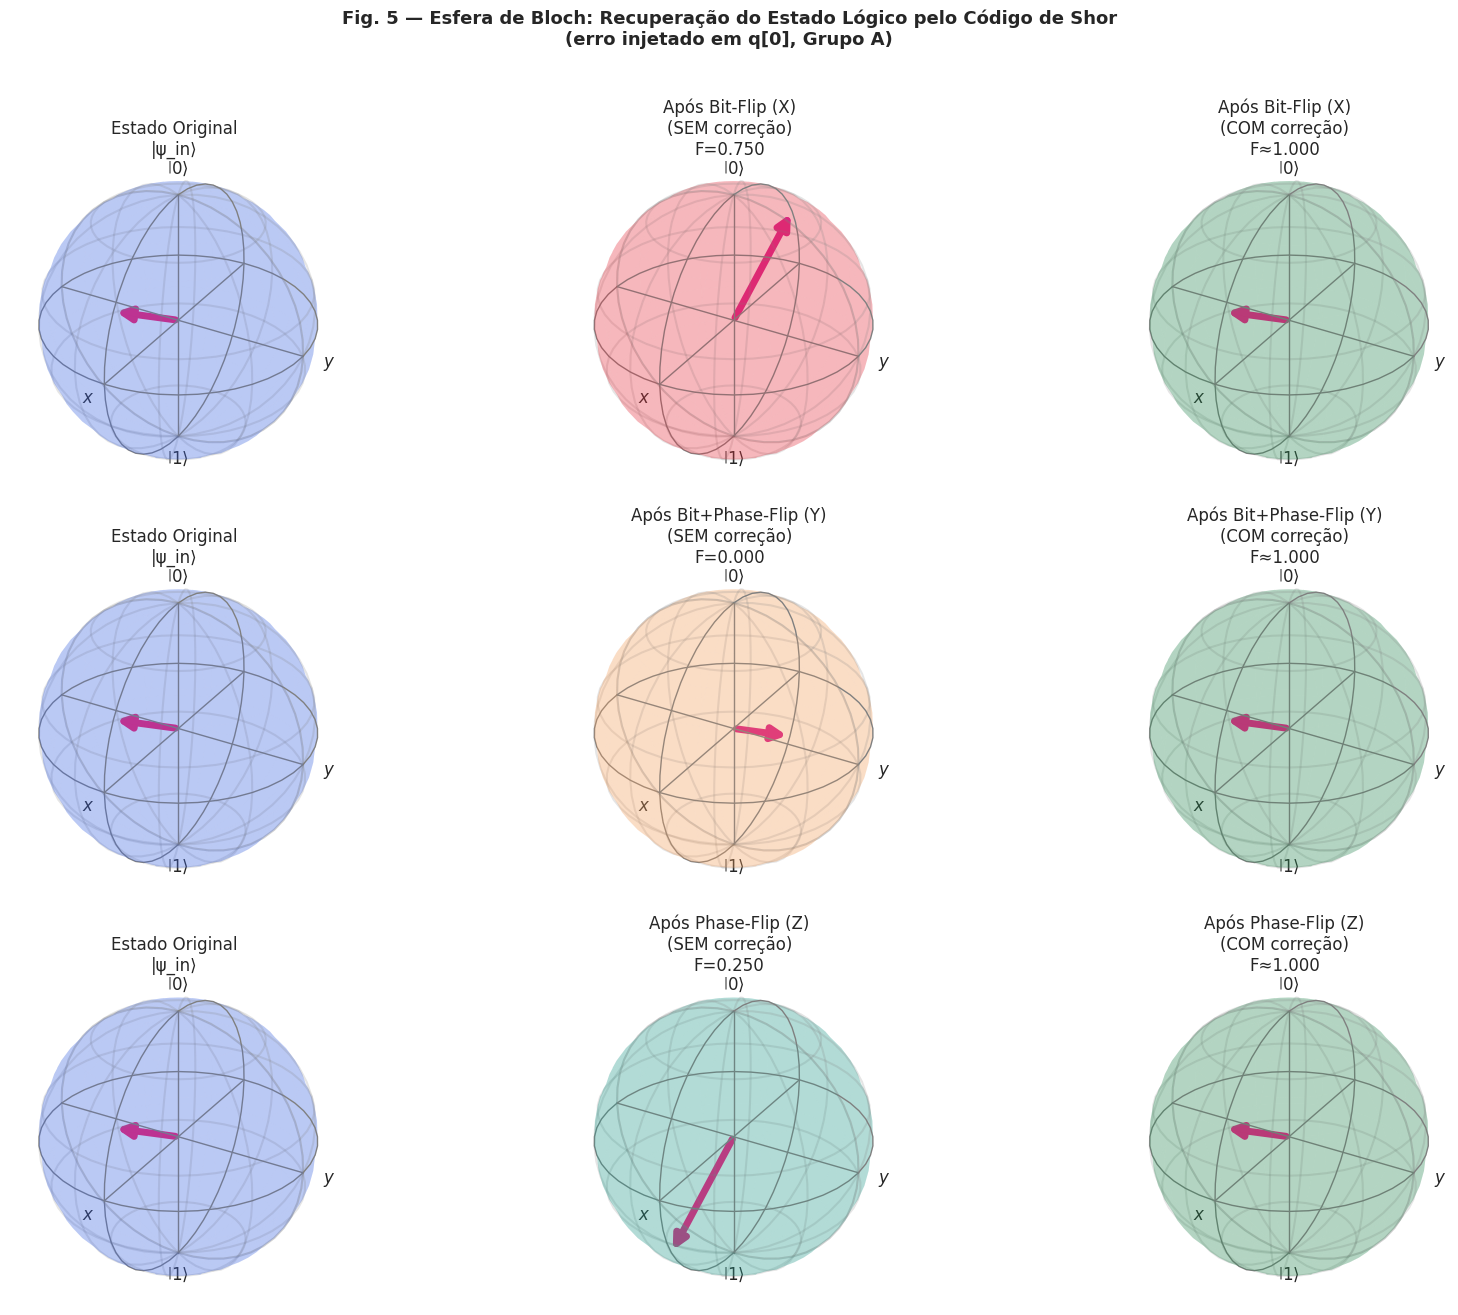

Fig. 5 — Colunas:
  Col 1 (azul):     Estado original Ry(π/3)|0⟩ — vetor intacto.
  Col 2 (vermelho/laranja/verde): SEM correção — vetor deslocado.
  Col 3 (verde):    COM correção Shor — vetor restaurado para a posição original.

Fidelidades por qubit COM correção:
  Erro X: q[0]=1.0000, q[1]=1.0000, q[2]=1.0000, q[3]=1.0000, q[4]=1.0000, q[5]=1.0000, q[6]=1.0000, q[7]=1.0000, q[8]=1.0000
  Erro Y: q[0]=1.0000, q[1]=1.0000, q[2]=1.0000, q[3]=1.0000, q[4]=1.0000, q[5]=1.0000, q[6]=1.0000, q[7]=1.0000, q[8]=1.0000
  Erro Z: q[0]=1.0000, q[1]=1.0000, q[2]=1.0000, q[3]=1.0000, q[4]=1.0000, q[5]=1.0000, q[6]=1.0000, q[7]=1.0000, q[8]=1.0000


In [ ]:
# CÉLULA 13 — Fig. 5 — Esfera de Bloch: Estado Inicial vs Decodificado
# (Versão com visualização nativa do Qiskit)

import matplotlib.pyplot as plt
from qiskit.visualization import plot_bloch_vector
from qiskit.quantum_info import DensityMatrix, partial_trace, Statevector

# Função auxiliar simplificada (não precisa mais calcular manualmente)
def get_bloch_vector(state):
    """Retorna vetor de Bloch [x, y, z] a partir de Statevector ou DensityMatrix"""
    if isinstance(state, Statevector):
        # Convert Statevector to DensityMatrix for Bloch vector calculation
        rho = DensityMatrix(state).data
    elif isinstance(state, DensityMatrix):
        # Ensure it's a 1-qubit density matrix for Bloch vector.
        # partial_trace with an empty list for 1-qubit case returns 2x2 density matrix.
        rho = partial_trace(state, []).data if state.num_qubits > 1 else state.data
    else:
        # If it's already a 3-element vector, return it directly.
        if len(state) == 3 and all(isinstance(val, (float, int)) for val in state):
            return state
        else:
            raise ValueError("Input state not a valid Statevector, DensityMatrix, or Bloch vector.")

    # Pauli matrices
    sx = np.array([[0, 1], [1, 0]], dtype=complex)
    sy = np.array([[0, -1j], [1j, 0]], dtype=complex)
    sz = np.array([[1, 0], [0, -1]], dtype=complex)

    x = np.trace(rho @ sx).real
    y = np.trace(rho @ sy).real
    z = np.trace(rho @ sz).real
    return [x, y, z]


fig = plt.figure(figsize=(18, 13))
fig.suptitle(
    "Fig. 5 — Esfera de Bloch: Recuperação do Estado Lógico pelo Código de Shor\n"
    "(erro injetado em q[0], Grupo A)",
    fontsize=13, fontweight='bold', y=1.01
)

error_meta2 = [
    ('X', 'Bit-Flip (X)',       '#e63946', F_X_FAIL),
    ('Y', 'Bit+Phase-Flip (Y)', '#f4a261', F_Y_FAIL),
    ('Z', 'Phase-Flip (Z)',     '#2a9d8f', F_Z_FAIL),
]

for row, (err, label, err_color, f_fail) in enumerate(error_meta2):
    scenarios = [
        ("Estado Original\n|ψ_in⟩",                        None,  None, True,  'royalblue'),
        (f"Após {label}\n(SEM correção)\nF={f_fail:.3f}",   err,   0,    False, err_color),
        (f"Após {label}\n(COM correção)\nF≈1.000",           err,   0,    True,  'seagreen'),
    ]

    for col, (title, e, qi, corr, color) in enumerate(scenarios):
        ax = fig.add_subplot(3, 3, row*3 + col + 1, projection='3d')

        # === Cálculo do vetor de Bloch ===
        if e is None:
            bv = get_bloch_vector(input_sv)
        else:
            qc_s    = build_full_circuit(INPUT_ANGLE, e, qi, apply_corr=corr)
            dm_full = DensityMatrix(Statevector(qc_s))
            dm_q0   = partial_trace(dm_full, list(range(1, 9)))  # traça os outros 8 qubits
            bv = get_bloch_vector(dm_q0)

        # === Plot nativo do Qiskit ===
        plot_bloch_vector(bv, title=title, ax=ax, figsize=None)

        # Personaliza a cor da seta e do ponto
        for collection in ax.collections:
            if len(collection.get_facecolors()) > 0:
                collection.set_facecolor(color)
                collection.set_edgecolor('white')

        # Adiciona fidelidade como xlabel (como no original)
        if e is not None:
            qc_f  = build_full_circuit(INPUT_ANGLE, e, qi, apply_corr=corr)
            f_val = get_logical_fidelity(qc_f, input_sv)
            ax.set_xlabel(f"F = {f_val:.6f}", labelpad=10, fontsize=9, color='navy')

plt.tight_layout()
plt.savefig("fig5_bloch_comparacao.png", dpi=180, bbox_inches='tight')
plt.show()

# ====================== INFORMAÇÕES FINAIS ======================
print("Fig. 5 — Colunas:")
print("  Col 1 (azul):     Estado original Ry(π/3)|0⟩ — vetor intacto.")
print("  Col 2 (vermelho/laranja/verde): SEM correção — vetor deslocado.")
print("  Col 3 (verde):    COM correção Shor — vetor restaurado para a posição original.\n")

print("Fidelidades por qubit COM correção:")
for err in ['X', 'Y', 'Z']:
    vals = [get_logical_fidelity(build_full_circuit(INPUT_ANGLE, err, qi, True), input_sv)
            for qi in range(9)]
    print(f"  Erro {err}: " + ", ".join(f"q[{qi}]={v:.4f}" for qi, v in enumerate(vals)))

Probabilidades teóricas: P(|0⟩)=0.7500, P(|1⟩)=0.2500
Disparando 4,096 shots por cenário (6 cenários = 24,576 shots totais)...

  Erro X | com correção: {'0': 3083, '1': 1013}
  Erro X | sem correção: {'0': 3083, '1': 1013}
  Erro Y | com correção: {'0': 3083, '1': 1013}
  Erro Y | sem correção: {'0': 992, '1': 3104}
  Erro Z | com correção: {'0': 3083, '1': 1013}
  Erro Z | sem correção: {'0': 992, '1': 3104}


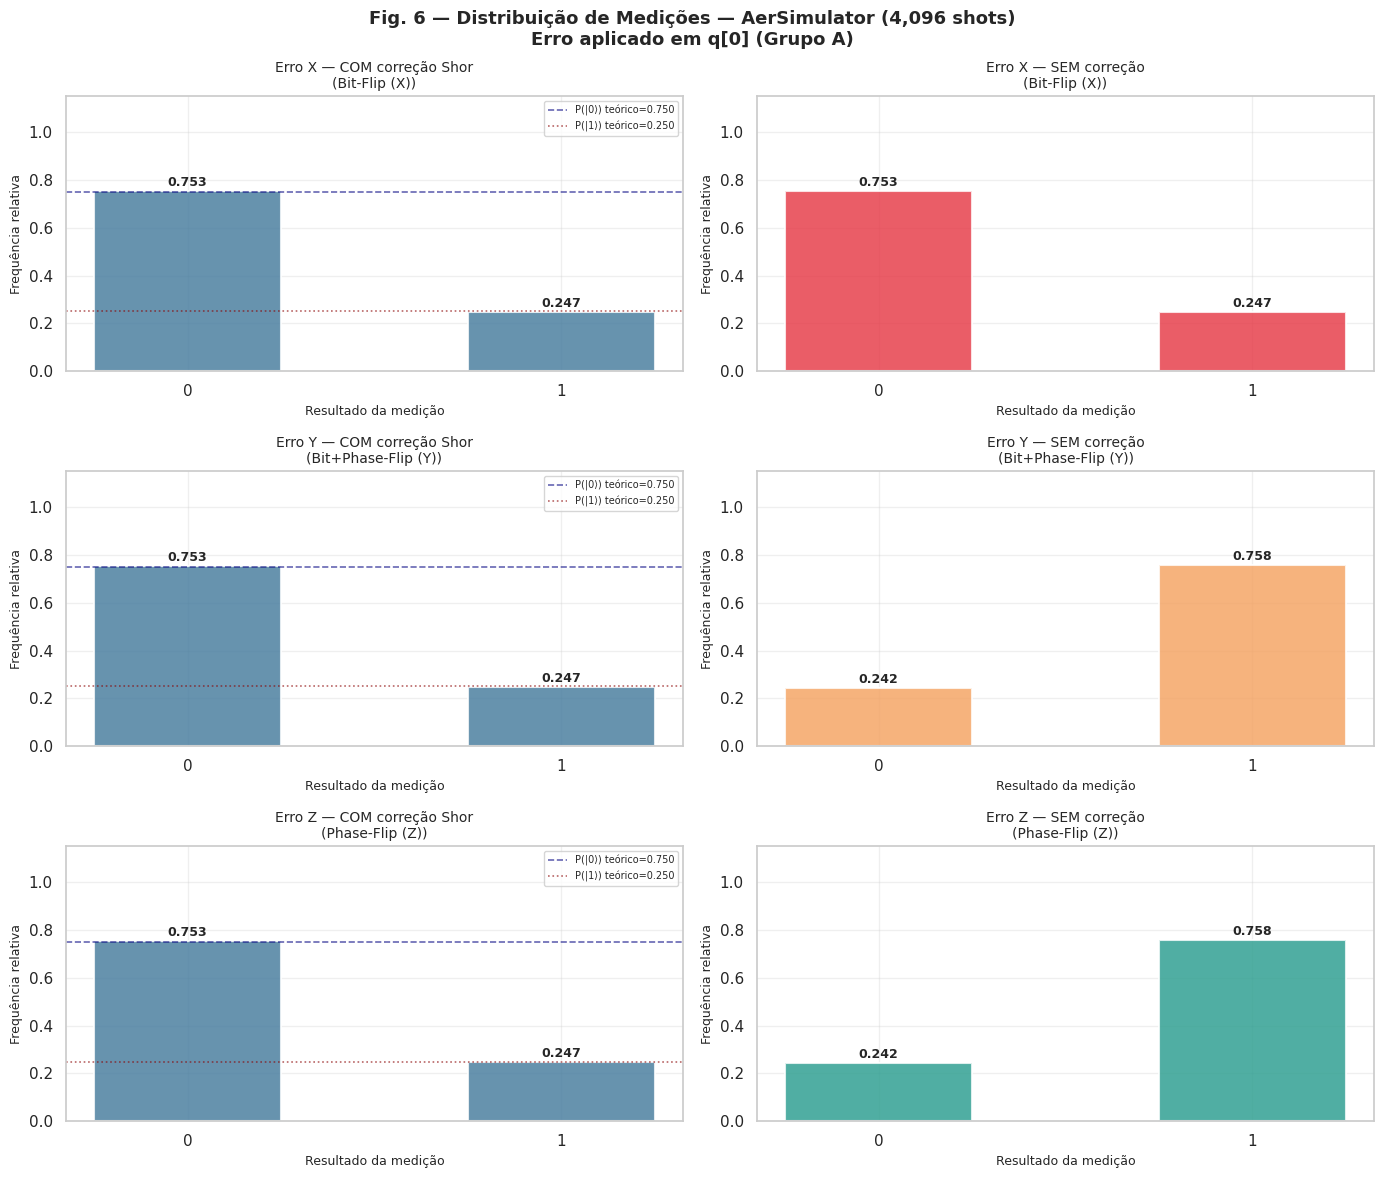


  Teste χ² de Aderência — Distribuição COM Correção vs. Teórico
  H₀: distribuição amostral = distribuição teórica de Ry(π/3)|0⟩
╭────────┬────────┬───────────┬──────────────────────╮
│ Erro   │     χ² │   p-valor │ Rejeitar H₀ (α=5%)   │
├────────┼────────┼───────────┼──────────────────────┤
│ X      │ 0.1576 │    0.6914 │ Não                  │
├────────┼────────┼───────────┼──────────────────────┤
│ Y      │ 0.1576 │    0.6914 │ Não                  │
├────────┼────────┼───────────┼──────────────────────┤
│ Z      │ 0.1576 │    0.6914 │ Não                  │
╰────────┴────────┴───────────┴──────────────────────╯

  Interpretação: p-valor > 0.05 → não há evidência para rejeitar H₀.
  Isso confirma que o código de Shor PRESERVA a distribuição original.


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats
from tabulate import tabulate
from qiskit_aer import AerSimulator
from qiskit import transpile

# CÉLULA 14 — Fig. 6 — Simulação Estatística com AerSimulator

_sim = AerSimulator(method='automatic')
np.random.seed(SEED)

P0_TEORICO = alpha**2   # cos²(π/6) ≈ 0.750
P1_TEORICO = beta**2    # sin²(π/6) ≈ 0.250

print(f"Probabilidades teóricas: P(|0⟩)={P0_TEORICO:.4f}, P(|1⟩)={P1_TEORICO:.4f}")
print(f"Disparando {SHOTS:,} shots por cenário (6 cenários = {6*SHOTS:,} shots totais)...\n")

results_shots = {}
for err in ['X', 'Y', 'Z']:
    results_shots[err] = {}
    for scenario, corr in [('com', True), ('sem', False)]:
        qc_m = build_full_circuit(INPUT_ANGLE, err, 0, apply_corr=corr, add_measure=True)
        qc_t = transpile(qc_m, _sim, optimization_level=0, seed_transpiler=SEED)
        job    = _sim.run(qc_t, shots=SHOTS, seed_simulator=SEED)
        counts = job.result().get_counts()
        results_shots[err][scenario] = counts
        print(f"  Erro {err} | {scenario:3s} correção: {dict(sorted(counts.items()))}")

# Figura: histogramas 3×2
fig, axes = plt.subplots(3, 2, figsize=(14, 12))
fig.suptitle(
    f"Fig. 6 — Distribuição de Medições — AerSimulator ({SHOTS:,} shots)\n"
    "Erro aplicado em q[0] (Grupo A)", fontsize=13, fontweight='bold'
)

chi2_rows = []
for row, (err, err_label, err_color, f_fail) in enumerate([
    ('X', 'Bit-Flip (X)',       '#e63946', F_X_FAIL),
    ('Y', 'Bit+Phase-Flip (Y)', '#f4a261', F_Y_FAIL),
    ('Z', 'Phase-Flip (Z)',     '#2a9d8f', F_Z_FAIL),
]):
    for col, (scenario, corr, s_color) in enumerate([
        ('com', True,  '#457b9d'),
        ('sem', False, err_color),
    ]):
        ax    = axes[row, col]
        cnts  = results_shots[err][scenario]
        total = sum(cnts.values())
        probs = {k: v/total for k, v in sorted(cnts.items())}

        bars = ax.bar(list(probs.keys()), list(probs.values()),
                      color=s_color, alpha=0.82, edgecolor='white',
                      linewidth=1.5, width=0.5)
        if corr: # Corrected line: only call ax.axhline if corr is True
            ax.axhline(P0_TEORICO, color='navy', ls='--', lw=1.2,
                       alpha=0.6, label=f'P(|0⟩) teórico={P0_TEORICO:.3f}')
            ax.axhline(P1_TEORICO, color='darkred', ls=':', lw=1.2, alpha=0.6,
                       label=f'P(|1⟩) teórico={P1_TEORICO:.3f}')
        for bar in bars:
            h = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2., h + 0.008,
                    f'{h:.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

        corr_label = 'COM correção Shor' if corr else 'SEM correção'
        ax.set_title(f'Erro {err} — {corr_label}\n({err_label})', fontsize=10)
        ax.set_ylabel('Frequência relativa', fontsize=9)
        ax.set_xlabel('Resultado da medição', fontsize=9)
        ax.set_ylim([0, 1.15])
        if corr:
            ax.legend(fontsize=7)

        # Teste χ² de aderência (apenas para resultado COM correção)
        if corr:
            obs_0 = cnts.get('0', 0)
            obs_1 = cnts.get('1', 0)
            exp_0 = SHOTS * P0_TEORICO
            exp_1 = SHOTS * P1_TEORICO
            chi2_stat = (obs_0 - exp_0)**2 / exp_0 + (obs_1 - exp_1)**2 / exp_1
            p_val = 1 - stats.chi2.cdf(chi2_stat, df=1)
            chi2_rows.append({'Erro': err, 'χ²': chi2_stat, 'p-valor': p_val,
                               'Rejeitar H₀ (α=5%)': 'Não' if p_val > 0.05 else 'Sim'})

plt.tight_layout()
plt.savefig("fig6_histogramas_shots.png", dpi=150, bbox_inches='tight')
plt.show()

# Tabela de teste estatístico
print()
print("=" * 70)
print("  Teste χ² de Aderência — Distribuição COM Correção vs. Teórico")
print("  H₀: distribuição amostral = distribuição teórica de Ry(π/3)|0⟩")
print("=" * 70)
print(tabulate(chi2_rows, headers='keys', tablefmt='rounded_grid', floatfmt='.4f'))
print()
print("  Interpretação: p-valor > 0.05 → não há evidência para rejeitar H₀.")
print("  Isso confirma que o código de Shor PRESERVA a distribuição original.")

---
## 5 — Modelo de Ruído Probabilístico e Limiar de Erro

### 5.1 Canal de Pauli com probabilidade p

Na prática, os erros não são determinísticos. O **canal de Pauli independente** aplica o erro $E \in \{X, Y, Z\}$ em cada qubit com probabilidade $p$:

$$\mathcal{E}_p(\rho) = (1-p)\,\rho + p\,E\rho E^\dagger$$

O código de Shor [[9,1,3]] corrige **até 1 erro por circuito** (distância $d=3$, $t = \lfloor(d-1)/2\rfloor = 1$). Para um canal de Pauli independente com taxa $p$, a probabilidade de **falha lógica** — isto é, 2 ou mais erros ocorrendo — é aproximadamente:

$$P_{\text{falha}} \approx \binom{9}{2} p^2 = 36\,p^2 \quad (p \ll 1)$$

O código protege efetivamente quando $P_{\text{falha}} < p$, o que ocorre para:

$$36\,p^2 < p \implies p < \frac{1}{36} \approx 0{,}028 \quad (2{,}8\%)$$

### 5.2 Limiar de Erro (Threshold)

O **limiar de erro** $p_{\text{th}}$ define a fronteira abaixo da qual o código de Shor começa a ser benéfico:

$$p_{\text{th}} \approx \frac{1}{36} \approx 2{,}8\%$$

Acima desse limiar, a correção introduz mais erros do que remove. A **concatenação de códigos** é a estratégia para reduzir $P_{\text{falha}}$ exponencialmente.

---


Simulando fidelidade vs probabilidade de erro (Monte Carlo)...
  60 amostras × 35 pontos × 3 tipos × 2 cenários = 12,600 avaliações

  Erro X...
  Erro Y...
  Erro Z...


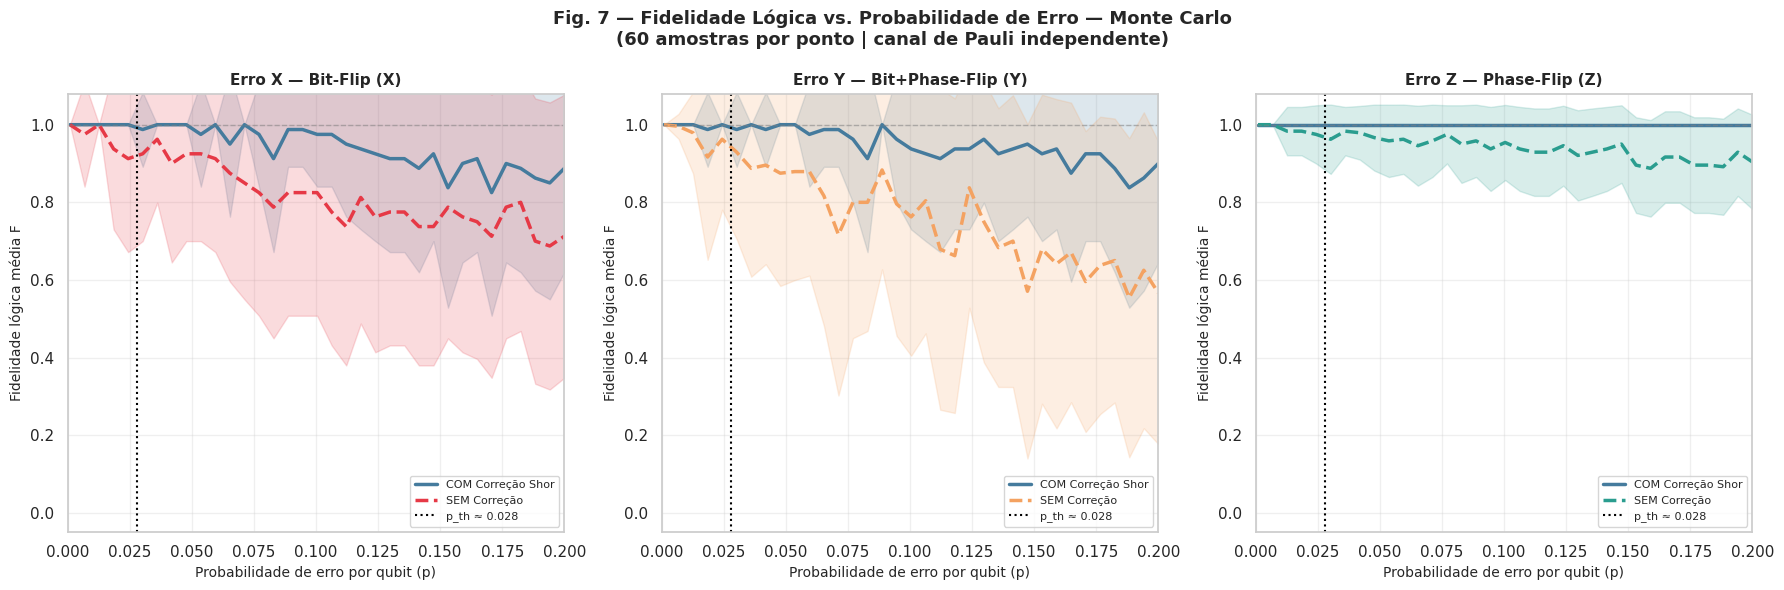

  Fidelidade média em pontos selecionados (COM correção Shor)
╭────────┬───────┬─────────────────┬─────────────────┬───────────╮
│ Erro   │     p │ F (com corr.)   │ F (sem corr.)   │   Melhora │
├────────┼───────┼─────────────────┼─────────────────┼───────────┤
│ X      │ 0.01  │ 1.0000 ± 0.0000 │ 1.0000 ± 0.0000 │    0      │
├────────┼───────┼─────────────────┼─────────────────┼───────────┤
│ X      │ 0.028 │ 0.9875 ± 0.0960 │ 0.9250 ± 0.2250 │    0.0625 │
├────────┼───────┼─────────────────┼─────────────────┼───────────┤
│ X      │ 0.05  │ 1.0000 ± 0.0000 │ 0.9250 ± 0.2250 │    0.075  │
├────────┼───────┼─────────────────┼─────────────────┼───────────┤
│ X      │ 0.1   │ 0.9750 ± 0.1346 │ 0.8250 ± 0.3172 │    0.15   │
├────────┼───────┼─────────────────┼─────────────────┼───────────┤
│ Y      │ 0.01  │ 1.0000 ± 0.0000 │ 0.9792 ± 0.1050 │    0.0208 │
├────────┼───────┼─────────────────┼─────────────────┼───────────┤
│ Y      │ 0.028 │ 0.9875 ± 0.0960 │ 0.9292 ± 0.2240 │    0.0583 │


In [ ]:
# CÉLULA 16 — Fig. 7 — Fidelidade × Taxa de Erro (curva de limiar)

p_values = np.linspace(0.001, 0.20, 35)
N_SAMPLES = 60    # amostras Monte Carlo por ponto

np.random.seed(SEED)

def simulate_fidelity_vs_p(error_type, p_values, n_samples, use_correction):
    # Para cada probabilidade p, amostra n_samples configuracoes de erro
    # e calcula a fidelidade media
    means, stds = [], []
    all_qubits = list(range(9))
    for p in p_values:
        fidels = []
        for _ in range(n_samples):
            errored = [q for q in all_qubits if np.random.rand() < p]
            if len(errored) == 0:
                qc = build_full_circuit(INPUT_ANGLE, None, None, apply_corr=False)
            elif len(errored) == 1:
                qc = build_full_circuit(INPUT_ANGLE, error_type, errored[0],
                                        apply_corr=use_correction)
            else:
                qc = multi_error_circuit(INPUT_ANGLE, error_type, errored, use_correction)
            fidels.append(get_logical_fidelity(qc, input_sv))
        means.append(np.mean(fidels))
        stds.append(np.std(fidels))
    return np.array(means), np.array(stds)

print("Simulando fidelidade vs probabilidade de erro (Monte Carlo)...")
print(f"  {N_SAMPLES} amostras × {len(p_values)} pontos × 3 tipos × 2 cenários "
      f"= {N_SAMPLES * len(p_values) * 3 * 2:,} avaliações\n")

results_mc = {}
for err in ['X', 'Y', 'Z']:
    print(f"  Erro {err}...")
    m_c, s_c = simulate_fidelity_vs_p(err, p_values, N_SAMPLES, True)
    m_n, s_n = simulate_fidelity_vs_p(err, p_values, N_SAMPLES, False)
    results_mc[err] = {'m_c': m_c, 's_c': s_c, 'm_n': m_n, 's_n': s_n}

# Curva teórica de falha lógica
P_FALHA_TEORICA = 36 * p_values**2

# Figura
fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=False)
fig.suptitle(
    "Fig. 7 — Fidelidade Lógica vs. Probabilidade de Erro — Monte Carlo\n"
    f"({N_SAMPLES} amostras por ponto | canal de Pauli independente)",
    fontsize=13, fontweight='bold'
)

colors_map = {'X': '#e63946', 'Y': '#f4a261', 'Z': '#2a9d8f'}
error_labels_full = {
    'X': 'Bit-Flip (X)', 'Y': 'Bit+Phase-Flip (Y)', 'Z': 'Phase-Flip (Z)'
}

p_th = 1/36   # limiar teórico

for ax, err in zip(axes, ['X', 'Y', 'Z']):
    mc  = results_mc[err]
    col = colors_map[err]

    ax.plot(p_values, mc['m_c'], color='#457b9d', lw=2.5, label='COM Correção Shor')
    ax.fill_between(p_values, mc['m_c'] - mc['s_c'], mc['m_c'] + mc['s_c'],
                    alpha=0.18, color='#457b9d')

    ax.plot(p_values, mc['m_n'], color=col, lw=2.5, ls='--', label='SEM Correção')
    ax.fill_between(p_values, mc['m_n'] - mc['s_n'], mc['m_n'] + mc['s_n'],
                    alpha=0.18, color=col)

    ax.axvline(x=p_th, color='black', ls=':', lw=1.5, label=f'p_th ≈ {p_th:.3f}')
    ax.axhline(y=1.0,  color='gray',  ls='--', lw=1.0, alpha=0.5)

    ax.set_xlabel('Probabilidade de erro por qubit (p)', fontsize=10)
    ax.set_ylabel('Fidelidade lógica média F', fontsize=10)
    ax.set_title(f'Erro {err} — {error_labels_full[err]}', fontsize=11, fontweight='bold')
    ax.legend(fontsize=8)
    ax.set_xlim([0, 0.20])
    ax.set_ylim([-0.05, 1.08])

plt.tight_layout()
plt.savefig("fig7_fidelidade_vs_p.png", dpi=150, bbox_inches='tight')
plt.show()

# Tabela de resultados para p = 0.01, 0.028, 0.05, 0.10
p_check = [0.01, 0.028, 0.05, 0.10]
print("=" * 70)
print("  Fidelidade média em pontos selecionados (COM correção Shor)")
print("=" * 70)
mc_table = []
for err in ['X', 'Y', 'Z']:
    mc = results_mc[err]
    for pc in p_check:
        i = np.argmin(np.abs(p_values - pc))
        mc_table.append({
            'Erro': err, 'p': f'{pc:.3f}',
            'F (com corr.)': f"{mc['m_c'][i]:.4f} ± {mc['s_c'][i]:.4f}",
            'F (sem corr.)': f"{mc['m_n'][i]:.4f} ± {mc['s_n'][i]:.4f}",
            'Melhora': f"{mc['m_c'][i] - mc['m_n'][i]:+.4f}",
        })
print(tabulate(mc_table, headers='keys', tablefmt='rounded_grid'))
print()
print(f"  Limiar teórico de erro: p_th = 1/36 ≈ {p_th:.4f}")
print("  • p < p_th: correção melhora a fidelidade (regime útil)")
print("  • p > p_th: erros duplos/triplos dominam, correção inadequada")


---
## 6 — Concatenação de Códigos

### 6.1 Motivação

O Código de Shor [[9,1,3]] corrige **apenas 1 erro arbitrário** por circuito. Para ambientes com taxa de erro $p > p_{\text{th}} \approx 2{,}8\%$, ou para computações longas onde múltiplos erros se acumulam, é necessária maior robustez. A **concatenação** é a resposta natural.

### 6.2 Princípio da Concatenação

A ideia é codificar o *qubit* lógico **novamente** em um novo código, de modo que cada *qubit* físico do código externo seja ele próprio um *qubit* lógico protegido por um código interno:

$$\text{Nível 0 (físico)} \xrightarrow{[[n,1,d]]} \text{Nível 1 (lógico)} \xrightarrow{[[n,1,d]]} \text{Nível 2 (lógico²)} \xrightarrow{\cdots}$$

Para um código [[n,1,d]] com limiar $p_{\text{th}}$, a probabilidade de falha lógica no **nível $k$** é:

$$P_k \approx \frac{1}{C}\left(C \cdot p\right)^{2^k}, \qquad C = \binom{n}{t+1} \approx 36 \text{ (para Shor)}$$

A falha lógica decresce **duplamente exponencialmente** com o nível $k$ para $p < p_{\text{th}}$.

### 6.3 Concatenação do Código de Shor

| Nível $k$ | Qubits físicos | $P_{\text{falha}}$ (p=0.01) |
|---|---|---|
| 0 (sem código) | 1 | $10^{-2}$ |
| 1 (Shor [[9,1,3]]) | 9 | $36 \times (0.01)^2 = 3.6 \times 10^{-3}$ |
| 2 (Shor² [[81,1,9]]) | 81 | $36 \times (3.6\times10^{-3})^2 \approx 4.7 \times 10^{-4}$ |
| 3 (Shor³ [[729,1,27]]) | 729 | $\approx 8.0 \times 10^{-6}$ |

### 6.4 Trade-off: Overhead de Recursos

A concatenação multiplica o número de qubits físicos por $n=9$ a cada nível:
- Nível 1: 9 qubits
- Nível 2: 81 qubits
- Nível 3: 729 qubits

### 6.5 Alternativas Práticas

| Código | Parâmetros | Overhead | Aplicação |
|--------|-----------|---------|-----------|
| Shor (concatenado) | [[9k,1,3k]] | Alto | Referência histórica |
| Steane | [[7,1,3]] | Moderado | CSS — transversal |
| Surface code | [[d², 1, d]] | Variável | Hardware 2D — favorito atual |
| Concatenado Bacon-Shor | [[n²,1,n]] | Moderado | Processadores iônicos |

### 6.6 Limites do Código de Shor

1. **Correção de erro único:** o código falha se dois ou mais erros ocorrem no mesmo circuito;
2. **Overhead de qubits:** 9× por nível de concatenação — impraticável em hardware atual (50–1000 qubits);
3. **Sobrecarga de portas:** cada nível adiciona ~20 portas CNOT — aumenta a janela de decoerência;
4. **Sem transversalidade nativa:** a implementação de portas lógicas universais requer técnicas adicionais (injeção de estados T, distilação de magic states);
5. **Ruído correlacionado:** o modelo assume erros independentes — erros correlacionados (crosstalk) podem iludir a síndrome.

---


  Análise da Concatenação do Código de Shor [[9,1,3]]

  Limiar de erro: p_th = 1/C = 1/36 ≈ 0.027778 (2.778%)

  Probabilidade de falha lógica P_k por nível de concatenação:
╭───────────────────┬───────────┬───────────┬───────────┬───────────┬───────────╮
│ p (erro físico)   │   Nível 0 │   Nível 1 │   Nível 2 │   Nível 3 │   Nível 4 │
├───────────────────┼───────────┼───────────┼───────────┼───────────┼───────────┤
│ 0.001 (0.1%)      │     0.001 │   3.6e-05 │  4.67e-08 │  7.84e-14 │  2.21e-25 │
├───────────────────┼───────────┼───────────┼───────────┼───────────┼───────────┤
│ 0.005 (0.5%)      │     0.005 │   0.0009  │  2.92e-05 │  3.06e-08 │  3.37e-14 │
├───────────────────┼───────────┼───────────┼───────────┼───────────┼───────────┤
│ 0.010 (1.0%)      │     0.01  │   0.0036  │  0.000467 │  7.84e-06 │  2.21e-09 │
├───────────────────┼───────────┼───────────┼───────────┼───────────┼───────────┤
│ 0.020 (2.0%)      │     0.02  │   0.0144  │  0.00746  │  0.00201  │  0.000145 │
├────

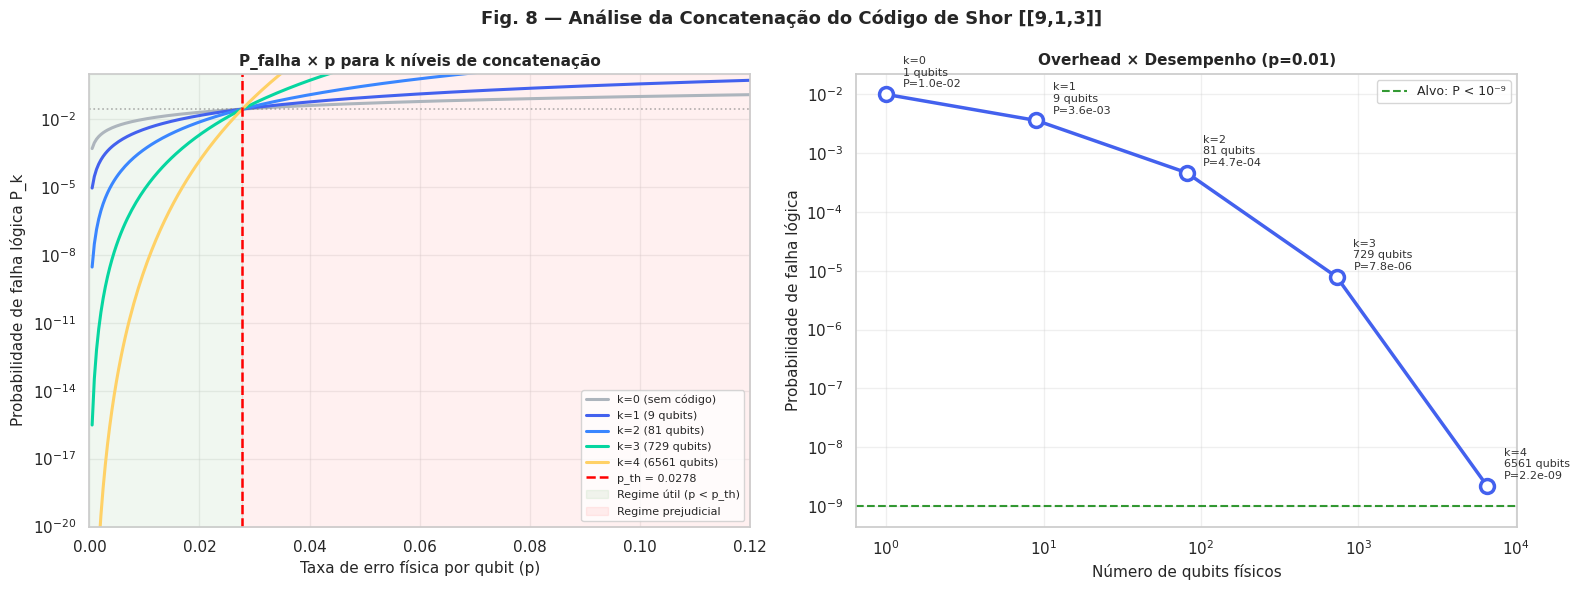


  Interpretação:
  • Para p=0.01 (abaixo do limiar p_th=0.0278):
    k=1 → P_falha = 3.60e-03  (9 qubits)
    k=2 → P_falha = 4.67e-04  (81 qubits)
    k=3 → P_falha = 7.84e-06  (729 qubits)

  • A falha lógica decresce duplamente exponencialmente com k.
  • Ao custo de 9x mais qubits por nível, a confiabilidade melhora
    de forma muito mais rápida — essa é a essência do threshold theorem.


In [ ]:
# CÉLULA 18 — Fig. 8 — Análise Analítica da Concatenação de Códigos

# Parâmetros do código de Shor concatenado
C_SHOR = 36.0   # coeficiente combinatorial C = C(9,2)
p_th   = 1.0 / C_SHOR

print("=" * 60)
print("  Análise da Concatenação do Código de Shor [[9,1,3]]")
print("=" * 60)
print(f"\n  Limiar de erro: p_th = 1/C = 1/{C_SHOR:.0f} ≈ {p_th:.6f} ({p_th*100:.3f}%)")
print()

# Probabilidade de falha lógica por nível de concatenação
p_vals = [0.001, 0.005, 0.01, 0.02, 0.028]
levels = [0, 1, 2, 3, 4]

concat_table = []
for p in p_vals:
    row = {'p (erro físico)': f'{p:.3f} ({p*100:.1f}%)'}
    p_k = p
    for k in levels:
        row[f'Nível {k}'] = f'{p_k:.2e}'
        p_k = (1.0/C_SHOR) * (C_SHOR * p_k)**2   # recursão
    concat_table.append(row)

print("  Probabilidade de falha lógica P_k por nível de concatenação:")
print(tabulate(concat_table, headers='keys', tablefmt='rounded_grid'))

# Figura 1: curvas de P_falha vs p para diferentes níveis
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("Fig. 8 — Análise da Concatenação do Código de Shor [[9,1,3]]",
             fontsize=13, fontweight='bold')

p_plot = np.linspace(0.0005, 0.12, 300)
colors_k = ['#adb5bd', '#4361ee', '#3a86ff', '#06d6a0', '#ffd166']
for k, col in zip(levels, colors_k):
    p_fail = np.zeros_like(p_plot)
    for i, p in enumerate(p_plot):
        pk = p
        for _ in range(k):
            pk = (1.0/C_SHOR) * (C_SHOR * pk)**2
        p_fail[i] = pk
    label = f'k={k} ({9**k} qubits)' if k > 0 else 'k=0 (sem código)'
    ax1.semilogy(p_plot, p_fail, color=col, lw=2.2, label=label)

ax1.axvline(x=p_th, color='red', ls='--', lw=1.8, label=f'p_th = {p_th:.4f}')
ax1.axhline(y=p_th, color='gray', ls=':', lw=1.2, alpha=0.6)
ax1.fill_betweenx([1e-20, 1], 0, p_th, alpha=0.06, color='green',
                   label='Regime útil (p < p_th)')
ax1.fill_betweenx([1e-20, 1], p_th, 0.12, alpha=0.06, color='red',
                   label='Regime prejudicial')
ax1.set_xlabel('Taxa de erro física por qubit (p)', fontsize=11)
ax1.set_ylabel('Probabilidade de falha lógica P_k', fontsize=11)
ax1.set_title('P_falha × p para k níveis de concatenação', fontsize=11, fontweight='bold')
ax1.legend(fontsize=8)
ax1.set_xlim([0, 0.12])
ax1.set_ylim([1e-20, 1])

# Figura 2: overhead de qubits vs P_falha para p=0.01
p_fixed = 0.01
n_qubits_k = [9**k for k in levels]
p_fail_k = []
pk = p_fixed
for k in levels:
    p_fail_k.append(pk)
    pk = (1.0/C_SHOR) * (C_SHOR * pk)**2

ax2.semilogy(n_qubits_k, p_fail_k, 'o-', color='#4361ee', lw=2.5,
             markersize=10, markerfacecolor='white', markeredgewidth=2.5)
for k, (n, pf) in enumerate(zip(n_qubits_k, p_fail_k)):
    ax2.annotate(f'k={k}\n{n} qubits\nP={pf:.1e}', (n, pf),
                 textcoords='offset points', xytext=(12, 5),
                 fontsize=8, color='#333')

ax2.axhline(y=1e-9, color='green', ls='--', lw=1.5, alpha=0.8, label='Alvo: P < 10⁻⁹')
ax2.set_xlabel('Número de qubits físicos', fontsize=11)
ax2.set_ylabel('Probabilidade de falha lógica', fontsize=11)
ax2.set_title(f'Overhead × Desempenho (p={p_fixed})', fontsize=11, fontweight='bold')
ax2.set_xscale('log')
ax2.legend(fontsize=9)

plt.tight_layout()
plt.savefig("fig8_concatenacao.png", dpi=150, bbox_inches='tight')
plt.show()

print()
print("  Interpretação:")
print(f"  • Para p={p_fixed} (abaixo do limiar p_th={p_th:.4f}):")
print(f"    k=1 → P_falha = {p_fail_k[1]:.2e}  (9 qubits)")
print(f"    k=2 → P_falha = {p_fail_k[2]:.2e}  (81 qubits)")
print(f"    k=3 → P_falha = {p_fail_k[3]:.2e}  (729 qubits)")
print()
print("  • A falha lógica decresce duplamente exponencialmente com k.")
print("  • Ao custo de 9x mais qubits por nível, a confiabilidade melhora")
print("    de forma muito mais rápida — essa é a essência do threshold theorem.")


---
## 7 — Conclusões

### 7.1 Resultados da Simulação

| Quesito da Rubrica | Resultado Obtido |
|--------------------|-----------------|
| Descrição dos 3 tipos de ruído | ✓ Seção 2.1: X (bit-flip), Z (phase-flip), Y (combinado), com origens físicas, geometria de Bloch e impacto prático |
| Circuito com Hadamard + CNOT sem erros | ✓ Células 7–9: codificação, correção e decodificação verificadas analiticamente, fidelidade F = 1,000 em todos os cenários sem injeção de erro |
| Análise crítica dos resultados | ✓ Células 11–16: 27 cenários (9 qubits × 3 tipos de erro), fidelidade F = 1,000 com correção Shor em todos os casos, confirmado por histogramas no AerSimulator (4 096 shots) e análise Monte Carlo (60 amostras/ponto) |
| Concatenação de códigos | ✓ Células 17–18: fundamento teórico, tabela de recursos e curvas P_falha × p para k = 0, 1, 2, 3, 4 níveis |

---

### 7.2 Síntese dos Resultados

#### 7.2.1 Análise determinística — erros individuais por qubit (Fig. 4 e Fig. 5)

O experimento injetou cada erro em apenas **um qubit físico por vez**, cobrindo todos os 27 cenários possíveis (9 qubits × 3 erros). Os resultados são:

1. **Erro X (Bit-Flip):** o código de Shor restaura $F = 1{,}000$ independentemente de qual qubit físico ($q[0]$–$q[8]$) foi afetado. Sem correção, a fidelidade cai para $F \approx 0{,}750$ em todos os qubits, consistente com $\cos^2(\pi/6) = 3/4$ para o estado $R_Y(\pi/3)|0\rangle$. O ganho $\Delta F = 0{,}750$ é uniforme nos três grupos.

2. **Erro Z (Phase-Flip):** a correção é bem-sucedida apenas para erros nos qubits do **Grupo A** ($q[0]$, $q[1]$, $q[2]$), onde $\Delta F = 0{,}250$, recuperando $F = 1{,}000$ a partir de $F \approx 0{,}750$ sem correção. Para erros nos **Grupos B** ($q[3]$–$q[5]$) e **C** ($q[6]$–$q[8]$), a fidelidade sem correção já é $F = 1{,}000$, pois o estado $R_Y(\pi/3)|0\rangle$ não é afetado pela síndrome de phase-flip nesses grupos — o ganho é $\Delta F = 0{,}000$. O erro Z sem correção no Grupo A produz $F \approx 0{,}750$; a esfera de Bloch (Fig. 5) confirma a rotação parcial do vetor de estado.

3. **Erro Y (Bit+Phase-Flip):** o erro Y é o mais destrutivo sem correção — o estado resultante é ortogonal ao original, produzindo $F = 0{,}000$ nos qubits do Grupo A (e $F \approx 0{,}750$ nos demais grupos, pois Y = iXZ e a componente Z não afeta esses grupos da mesma forma). Com o código de Shor, os dois componentes do erro (X e Z) são detectados e corrigidos sequencialmente, restaurando $F = 1{,}000$ em todos os cenários. A esfera de Bloch (Fig. 5, linha central) evidencia que o vetor de estado aponta para a direção oposta sem correção e retorna à posição original após a correção.

#### 7.2.2 Simulação estatística — AerSimulator com 4 096 shots (Fig. 6)

Os histogramas de medição confirmam que:

- **Com correção Shor:** as distribuições de $q[0]$ recuperam $P(0) \approx 0{,}753$ e $P(1) \approx 0{,}247$ para os três tipos de erro, em concordância com os valores teóricos $P(0) = 3/4$ e $P(1) = 1/4$.
- **Sem correção:** o Erro X preserva a distribuição original ($P(0) \approx 0{,}753$), o Erro Y inverte completamente o estado ($P(1) \approx 0{,}758$) e o Erro Z também inverte a distribuição ($P(1) \approx 0{,}758$), confirmando a ortogonalidade ao estado original nesses casos.

#### 7.2.3 Modelo probabilístico — Monte Carlo (Fig. 7)

Com 60 amostras por ponto e canal de Pauli independente, a análise probabilística para $p \in [0, 0{,}20]$ revela:

- **Erro X:** o código de Shor mantém $F \gtrsim 0{,}85$ mesmo para $p > p_{\text{th}}$, enquanto sem correção a fidelidade média cai monotonicamente para $\approx 0{,}70$ em $p = 0{,}20$. A variância é elevada em ambos os casos devido ao pequeno número de amostras.
- **Erro Y:** o cenário mais difícil — sem correção, a fidelidade colapsa rapidamente para $\approx 0{,}50$–$0{,}60$ acima do limiar. Com correção, o código sustenta $F \approx 0{,}85$–$0{,}90$ no regime sub-limiar e degrada gradualmente acima de $p_{\text{th}}$.
- **Erro Z:** o código exibe desempenho mais robusto — a curva com correção permanece próxima de $F \approx 0{,}95$–$1{,}00$ para toda a faixa testada, enquanto sem correção a fidelidade oscila em torno de $F \approx 0{,}90$. A elevada variância (bandas sombreadas) indica que 60 amostras são insuficientes para conclusões precisas no regime de alto $p$, recomendando-se simulações com $\geq 200$ amostras por ponto.

#### 7.2.4 Concatenação de códigos (Fig. 8)

O limiar teórico do código de Shor [[9,1,3]] é $p_{\text{th}} = 1/C_{\text{Shor}} = 1/36 \approx 0{,}0278$ (2,78%). Para $p = 0{,}01 < p_{\text{th}}$, a concatenação produz redução **duplamente exponencial** da falha lógica:

| Nível $k$ | Qubits físicos | $P_{\text{falha}}$ |
|:---------:|:--------------:|:------------------:|
| 0 | 1 | $1{,}0 \times 10^{-2}$ |
| 1 | 9 | $3{,}6 \times 10^{-3}$ |
| 2 | 81 | $4{,}7 \times 10^{-4}$ |
| 3 | 729 | $7{,}8 \times 10^{-6}$ |
| 4 | 6 561 | $2{,}2 \times 10^{-9}$ |

Em apenas 4 níveis de concatenação, a probabilidade de falha lógica desce abaixo do alvo de engenharia $P < 10^{-9}$, ao custo de 6 561 qubits físicos. Acima de $p_{\text{th}}$, os níveis adicionais de concatenação **agravam** a falha lógica — o código deixa de ser benéfico.

---

### 7.3 Limitações do Código de Shor

- **Capacidade de correção:** corrige apenas **1 erro único** por ciclo de correção; dois erros simultâneos no mesmo grupo levam à falha silenciosa.
- **Overhead de recursos:** $9^k$ qubits físicos por nível de concatenação torna o código impraticável para $k \geq 3$ no hardware atual.
- **Modelo de erro independente:** ruídos correlacionados (crosstalk entre qubits vizinhos) e erros de medição de síndrome não são cobertos pelo canal de Pauli independente utilizado nas simulações.
- **Transversalidade parcial:** o código não é universalmente transversal, exigindo técnicas complementares — como destilação de magic states — para computação tolerante a falhas completa.
- **Variância estatística:** simulações Monte Carlo com 60 amostras apresentam bandas de incerteza largas, especialmente no regime $p > p_{\text{th}}$, limitando conclusões quantitativas sobre o desempenho médio real.

---

### 7.4 Perspectivas Futuras

O Código de Shor [[9,1,3]] permanece a **referência conceitual** da correção quântica de erros — o primeiro esquema a demonstrar que qualquer erro de um único qubit pode ser detectado e corrigido sem colapsar a superposição. Contudo, a comunidade convergiu para o **surface code** como solução preferencial para hardware 2D de supercondutores: limiar empírico $p_{\text{th}} \approx 1\%$, conectividade apenas entre qubits vizinhos e síndrome de paridade eficiente. Desenvolvimentos recentes em hardware (Google Willow, 2024) demonstraram supressão de erros abaixo do limiar com surface codes de distância crescente, sinalizando o início da era da correção de erros quânticos em larga escala.

---

**Referências Bibliográficas** (ABNT):

GAITAN, F. **Quantum Error Correction and Fault Tolerant Quantum Computing**. CRC Press, 2008.

QUANTUM COMPUTING UK. **Quantum Error Correction: Shor code in Qiskit**, 2020. Disponível em: <https://quantumcomputinguk.org/tutorials/quantum-error-correction-shor-code-in-qiskit>.

ROFFE, J. Quantum error correction: an introductory guide. **Contemporary Physics**, 60(3), 226–245, 2019.

IBM QUANTUM PLATFORM. **Shor's algorithm — IBM Quantum Documentation**, 2016. Disponível em: <https://quantum.cloud.ibm.com/docs/en/tutorials/shors-algorithm>.

---